# Start
I started looking for research methods to better understand and frame my PhD research, and I found this [repository from Anton Savov](https://github.com/antonsavov/research-maps/) and thought it would be a very interesting first step towards the state-of-the-art in Digital Design in Architecture.

I used his work as a template, but used Python only, no R stuff, in part because I'm not familiar with R, and in part because the repo is now a bit old, so I had to make an enviroment "from scratch". At first I tried using Scopus data for the analysis, but that proved to be a lot more difficult than expected, because the metaknowledge package is not correctly reading the current Scopus exports (as of May 2026). So, this is my second attempt at it, this time with WoS data.

# INIT

First let's start by loading the packages

In [1]:
import os
import csv
import umap
import hdbscan
import requests
import re
import copy
import random
import textwrap
import string

import metaknowledge as mk
import pandas as pd
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from collections import defaultdict
from collections import Counter
from itertools import chain
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import coo_matrix, vstack
from scipy.sparse import csr_matrix
from scipy.stats import gaussian_kde
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d
from matplotlib import cm
from matplotlib import rc
from matplotlib.colors import to_hex, LinearSegmentedColormap
from ipysankeywidget import SankeyWidget
from ipywidgets import Layout
from IPython.display import Image, SVG
from datetime import datetime
from pathlib import Path

In [2]:
# -- Other configurations

pd.set_option('display.max_columns', None) # show all cols
pd.set_option('display.max_colwidth', 50) # None -> show full width of showing cols AND 50 -> for less content
#pd.set_option('display.expand_frame_repr', False) # print cols side by side as it's supposed to be

#pd.reset_option('display.max_colwidth') # resets option (change the parameter inside parenthesis)

# Data Handling
All the data comes from the same list of publications as Savov had, although updated to mid 2026.
The database used was Web of Science (Wos), but I exported everything as "Plain Text Files" with the "Record Content option" set as "Full Record and Cited References".

There is another file with the search queries.
The list is bellow, with the amount of papers found for each entry.

In [3]:
%%time
df_sources = pd.read_csv("data/publication_sources.csv", encoding='utf-8')
display(df_sources)

,PUBLICATION TITLE,ARTICLES ON WOS
0,ACADIA,226
1,ADVANCES IN ARCHITECTURAL GEOMETRY (AAG),22
2,AI EDAM ARTIFICIAL INTELLIGENCE FOR ENGINEERIN...,1043
3,ARCHITECTURAL DESIGN,7235
4,AUTOMATION IN CONSTRUCTION,6033
5,CAAD FUTURES,396
6,CAADRIA,940
7,COMPUTER AIDED DESIGN,4519
8,DESIGN STUDIES,759
9,ECAADE,1913


CPU times: total: 15.6 ms
Wall time: 7.58 ms


Let's check how many papers in total

In [4]:
%%time
RC = mk.RecordCollection("data/publications")
print(RC.glimpse())

RecordCollection glimpse made at: 2026-06-15 15:33:41
27603 Records from files-from-D:\OneDrive - Unive

Top Authors
1 [Anonymous]
2 TOY, M
3 Menges, Achim
3 Spiller, Neil
4 JENCKS, C
5 Toy, M
6 Castle, H
6 Cheng, Jack C. P.
7 Castle, Helen
8 Li, Heng
9 COOKE, C
10 Zhang, Limao
11 Wang, Jun
12 Batty, Michael
13 Wang, Xiangyu
14 Fukuda, Tomohiro
15 Stouffs, Rudi
16 BATTY, M
17 Batty, M
18 Gero, John S.
18 Burry, Jane
18 Brilakis, Ioannis
18 Ding, Lieyun
19 Ostwald, Michael J.
19 Zayed, Tarek
20 Luo, Hanbin
20 PORPHYRIOS, D
20 Melvin, J
21 Williams, Kim
21 PAPADAKIS, AC
21 Duarte, Jose Pinto
22 Janssen, Patrick

Top Journals
1 ARCHITECTURAL DESIGN
2 AUTOMATION IN CONSTRUCTION
3 COMPUTER-AIDED DESIGN
4 ENVIRONMENT AND PLANNING B-PLANNING & DESIGN
5 AI EDAM-ARTIFICIAL INTELLIGENCE FOR ENGINEERING DESIGN ANALYSIS AND MANUFACTURING
6 NEXUS NETWORK JOURNAL
7 DESIGN STUDIES
8 TECHNE-JOURNAL OF TECHNOLOGY FOR ARCHITECTURE AND ENVIRONMENT
9 INTERNATIONAL JOURNAL OF ARCHITECTURAL COMPUTING
10 PRO

Now we need to clean this data.

As per Savov's instructions, we will remove the articles which have less then a certain number of citations to reduce the noise in the map.
We can also remove all articles that don't list the year of their publication, or are without abstracts. This helps later when we want to understand what each cluster is researching about.

Let's print a glimpse of the data so far.

In [5]:
%%time
# -- Creates a new emtpy collection of records
# -- It'll be used as a temp storage of the papers that pass the criteria we defined
RC2 = mk.RecordCollection()

for R in RC:
    if len(R.getCitations().get("author"))>=3:
        # -- Here we kick out every paper that cites less then 3 authors. Why? because they
        #                   are so dissimilar from the others, that they only produce noise.  
   
        try:
            R['year']
            R['abstract']   # -- Add this when working with abstracts. It removes every paper that has none. 
                            # -- This can sometimes remove whole journals, that are archived without abstracts, so handle with care.
            RC2.add(R)
        except KeyError:
            pass
    else:
        pass
    

print(RC2.glimpse())

# -- Pass the values from the temporary collection to the main one.
RC = RC2

RecordCollection glimpse made at: 2026-06-15 15:33:42
17326 Records from Empty

Top Authors
1 Cheng, Jack C. P.
2 Menges, Achim
3 Li, Heng
4 Zhang, Limao
5 Wang, Jun
6 Wang, Xiangyu
7 Stouffs, Rudi
8 Fukuda, Tomohiro
9 Brilakis, Ioannis
10 Ding, Lieyun
10 Zayed, Tarek
11 Luo, Hanbin
12 Gero, John S.
13 Duarte, Jose Pinto
14 Janssen, Patrick
14 Yabuki, Nobuyoshi
14 Burry, Jane
15 Al-Hussein, Mohamed
15 Fioravanti, Antonio
15 Elber, Gershon
16 Yan, Wei
16 Cheng, Min-Yuan
16 Wang, Qian
17 Achten, Henri
17 Haeusler, M. Hank
17 Love, Peter E. D.
18 Gu, Ning
19 Wang, Charlie C. L.
19 Tang, Kai
19 Lee, Ghang
19 Leitao, Antonio
20 He, Ying

Top Journals
1 AUTOMATION IN CONSTRUCTION
2 COMPUTER-AIDED DESIGN
3 ENVIRONMENT AND PLANNING B-PLANNING & DESIGN
4 AI EDAM-ARTIFICIAL INTELLIGENCE FOR ENGINEERING DESIGN ANALYSIS AND MANUFACTURING
5 NEXUS NETWORK JOURNAL
6 DESIGN STUDIES
7 ARCHITECTURAL DESIGN
8 TECHNE-JOURNAL OF TECHNOLOGY FOR ARCHITECTURE AND ENVIRONMENT
9 INTERNATIONAL JOURNAL OF ARCHITE

We still have more than 17k records, great!

Next let's assemble a clean list of all included journals and conferences so we can print it next to the map.

In [6]:
%%time
# -- List all journals where the papers in the data were published ranked by occurence
topJU = RC.rankedSeries(tag='journal', pandasMode=False)

# -- Conference proceedings or journals sometimes appear as separate journals for each year or issue
# -- Lets combine them
# -- Define regex patterns and their replacement names
# -- The (?i) flag makes the search case-insensitive
# -- The | operator acts as an "OR", meaning 'ecaade|fusion:' matches either word
conf_mapping = {
    # -- Map of what to search for (in regex) and what to change the name to
    re.compile(r'(?i)acadia'): 'ACADIA CONFERENCE PROCEEDINGS',
    re.compile(r'(?i)ecaade|fusion:|anthropocene'): 'ECAADE CONFERENCE PROCEEDINGS',
    re.compile(r'(?i)caadria'): 'CAADRIA CONFERENCE PROCEEDINGS',
    re.compile(r'(?i)simaud'): 'SIMAUD CONFERENCE PROCEEDINGS',
    re.compile(r'(?i)ADVANCES IN ARCHITECTURAL GEOMETRY'): 'AAG CONFERENCE PROCEEDINGS',
    re.compile(r'(?i)caad futures|computer[- ]aided architectural design.*future|DIGITAL DESIGN: RESEARCH AND PRACTICE'): 'CAAD FUTURES CONFERENCE PROCEEDINGS',
}

# -- Use defaultdict to automatically handle adding new entries
aggregated_journals = defaultdict(int)

for jouName, count in topJU:
    # -- Check if the journal name matches any of our regex patterns
    for pattern, target_name in conf_mapping.items():
        if pattern.search(jouName):
            jouName = target_name
            break # -- Stop checking other patterns once we find a match
            
    # -- Add the count. If jouName is new, defaultdict initializes it to 0 first.
    aggregated_journals[jouName] += count

# -- Sort alphabetically by journal name
sorted_journals = sorted(aggregated_journals.items(), key=lambda x: x[0])

# -- Format the strings
wrapper = textwrap.TextWrapper(width=60, initial_indent="", subsequent_indent="    ")

journalListLabels = [
    wrapper.fill(f"{name} ({count})") for name, count in sorted_journals
]

# -- Gets date and formats it
now = datetime.now()
formatted_date = now.strftime("%Y %b %d").upper()

journalListLabel = (
    "THE MAP IS GENERATED FROM DATA FROM THE FOLLOWING PUBLICATIONS:\n\n" +
    "\n".join(journalListLabels) +
    f"\n\nDATA SNAPSHOT {formatted_date}"
)

print(journalListLabel)

THE MAP IS GENERATED FROM DATA FROM THE FOLLOWING PUBLICATIONS:

AAG CONFERENCE PROCEEDINGS (22)
ACADIA CONFERENCE PROCEEDINGS (112)
AI EDAM-ARTIFICIAL INTELLIGENCE FOR ENGINEERING DESIGN
    ANALYSIS AND MANUFACTURING (888)
ARCHITECTURAL DESIGN (579)
AUTOMATION IN CONSTRUCTION (5949)
CAAD FUTURES CONFERENCE PROCEEDINGS (284)
CAADRIA CONFERENCE PROCEEDINGS (857)
COMPUTER-AIDED DESIGN (3333)
DESIGN STUDIES (698)
ECAADE CONFERENCE PROCEEDINGS (1909)
ENVIRONMENT AND PLANNING B-PLANNING & DESIGN (1299)
INTERNATIONAL JOURNAL OF ARCHITECTURAL COMPUTING (223)
NEXUS NETWORK JOURNAL (803)
SIMAUD CONFERENCE PROCEEDINGS (105)
TECHNE-JOURNAL OF TECHNOLOGY FOR ARCHITECTURE AND
    ENVIRONMENT (265)

DATA SNAPSHOT 2026 JUN 15
CPU times: total: 0 ns
Wall time: 12.7 ms


# MAP
Now that your data is clean and the sources organised we can start making the map.

This is kinda complicated, but I did my best to explain what I understand from the code.

## Build a multi-dimensional space of relationships
In order to arrange the publications in a 2D map (which is done with UMAP), and subsequently to determine the clusters, the publications datapoints need to be assigned features. The datapoints with more similar features will be placed closer to each other. Max Noichl carried out some experiments with features such as author, words in abstracts, title and so on and he recommends using the following two features:

- the cited works
- the cited authors

To extract the features we use scikit-learn and clean up the weakly linked points.

First let's do the cited works, then the cited authors and then filter out weak links.

In [7]:
%%time
# -- Creates a Pandas DataFrame from RecordCollection
#        with only the columns for NLP (Natural Language Processing: id, title, publication year, keywords, abstract),
#        plus the columns specified in the "extraColumns" list.
#        ( AU = Authors | Z9 = Total Times Cited Count )
drc = pd.DataFrame.from_dict(RC.forNLP(extraColumns=['journal','AU','Z9']))

# -- Fetch citations once per item to save processing time
citations = [R.getCitations() for R in RC]

# -- Using list comprehensions to extract unique values
# -- ".get("author", [])" the empty brackets are there in case a record doesn't have any citations
# -- because otherwise it would return None, which causes set(None) to throw an error. "[]" acts as a fail-safe
#drc["citedAU"] = [list(set(c.get("author", []))) for c in citations] # -- Used cell below to format names
#drc["citeString"] = [list(set(c.get("citeString", []))) for c in citations]

CPU times: total: 1.86 s
Wall time: 1.87 s


In [8]:
%%time
#citedAU = [list(set(c.get("author", []))) for c in citations]

remove_set = set(['[Anonymous]', '[No Title Captured]'])

def format_to_remove_set(author_str):
    if author_str == None:
        #print('None')
        return None

    if author_str in remove_set:
        #print('Removed')
        return None

    return author_str

def format_to_surname_initial(author_str):
    if author_str == None:
        #print('None')
        return None

    if author_str in remove_set:
        #print('Removed')
        return None
    
    # Split the name by spaces
    parts = author_str.strip().split()
    
    if not parts:
        #print('ping')
        return ""
    
    surname = parts[0]
    
    # If there's a first name/initial available, get the first letter
    if len(parts) > 1:
        initial = parts[1][0].upper()
        return f"{surname} {initial}"
    
    return surname

def format_to_surname_only(author_str):
    if author_str == None:
        #print('None')
        return None

    if author_str in remove_set:
        #print('Removed')
        return None
    
    # Split the name by spaces
    parts = author_str.strip().split()
    
    if not parts:
        #print('ping')
        return ""
    
    surname = parts[0]

    return surname

formatted_citations = []

for c in citations:
    raw_authors = c.get("author", [])
    
    # Format each author and use a set to remove duplicates
    unique_formatted = {format_to_remove_set(author) for author in raw_authors}
    
    # Filter out any empty strings and convert to list
    formatted_citations.append([auth for auth in unique_formatted if auth])

drc['citedAU'] = formatted_citations

CPU times: total: 125 ms
Wall time: 125 ms


In [9]:
%%time
#"citeString" = [list(set(c.get("citeString", []))) for c in citations]

remove_invalid = set(['[No title captured]', '[Anonymous], THESIS'])

def format_to_remove_invalid(paper_str):
    if paper_str == None:
        #print('None')
        return None

    if paper_str in remove_invalid:
        #print('Removed')
        return None

    return paper_str

formatted_citations = []

for c in citations:
    raw_papers = c.get("citeString", [])
    
    # Format each author and use a set to remove duplicates
    unique_formatted = {format_to_remove_invalid(paper) for paper in raw_papers}
    
    # Filter out any empty strings and convert to list
    formatted_citations.append([paper for paper in unique_formatted if paper])

drc['citeString'] = formatted_citations

CPU times: total: 156 ms
Wall time: 166 ms


In [10]:
%%time
remove_invalid = set(['[No title captured]', '[Anonymous], THESIS'])

def get_doi_from_paper(paper):
    if paper == None:
        return None

    if paper in remove_invalid:
        return None
        
    match = re.search(r"doi.*$", paper, re.IGNORECASE)

    if match:
        match = match.group()
        match = match.translate(str.maketrans("", "", "[]"))
        match = match.lower().split()[-1]
        
        if not match.strip():
            return None
        else:
            return match

    return None 
    
formatted_citations = []

for c in citations:
    raw_string = c.get("citeString", [])
    
    # Format each author and use a set to remove duplicates
    unique_formatted = {get_doi_from_paper(paper) for paper in raw_string}
    
    # Filter out any empty strings and convert to list
    formatted_citations.append([doi for doi in unique_formatted if doi])

drc["citedDOI"] = formatted_citations

#print(drc["citedDOI"][0])

CPU times: total: 984 ms
Wall time: 1.02 s


In [11]:
%%time
# -- Creates authors and papers list directly from the dataframe column
cited_authors_list = ['§'.join(filter(None, x)) for x in drc["citedAU"]]   # -- AUTHORS - FEATURES
cited_papers_list = ['§'.join(filter(None, x)) for x in drc["citeString"]] # -- CITATIONS - FEATURES
cited_doi_list = ['§'.join(filter(None, x)) for x in drc["citedDOI"]]      # -- DOI - FEATURES

CPU times: total: 78.1 ms
Wall time: 76.9 ms


---
VIEW MOST CITED AUTHORS

In [12]:
%%time
top_authors = drc["citedAU"].explode().dropna().value_counts().head(999).items()

# -- Displays the results
print(f"### | {'Name':<16} | {'Count':<5}")
print("-" * 30)
spot = 0
for entry, count in top_authors:
    spot += 1
    print(f"{spot:03d} | {entry:<16} | {f'{count:03d}':<5}")

### | Name             | Count
------------------------------
001 | Cross N          | 482  
002 | Stiny G          | 476  
003 | Eastman C        | 422  
004 | Kim H            | 421  
005 | Liu Y            | 419  
006 | Gero Js          | 411  
007 | Li H             | 410  
008 | Wang Y           | 410  
009 | Batty M          | 397  
010 | Li X             | 396  
011 | Wang J           | 391  
012 | He Km            | 371  
013 | Sacks R          | 364  
014 | Kim J            | 362  
015 | Lee J            | 330  
016 | Zhang Y          | 327  
017 | Zhang H          | 304  
018 | Zhang C          | 298  
019 | Pottmann H       | 292  
020 | Goldschmidt G    | 286  
021 | Schon D          | 284  
022 | Piegl L          | 280  
023 | Liu Z            | 275  
024 | Dorst K          | 274  
025 | Chen Y           | 273  
026 | Oxman R          | 271  
027 | Wang X           | 271  
028 | Schon Da         | 269  
029 | Kim S            | 267  
030 | Yang J           | 264  
031 | Ch

---
VIEW MOST CITED PAPERS

In [13]:
%%time
top_papers = drc["citeString"].explode().dropna().value_counts().head(999).items()

print(f"### | {'Name':<100} | {'Count':<5}")
print("-" * 114)
spot = 0
for entry, count in top_papers:
    spot += 1
    print(f"{spot:03d} | {f'{entry:.100}':<100} | {f'{count:03d}':<5}")

### | Name                                                                                                 | Count
------------------------------------------------------------------------------------------------------------------
001 | He KM, 2016, PROC CVPR IEEE, P770, DOI 10.1109/CVPR.2016.90                                          | 284  
002 | Schon D., 1982, REFLECTIVE PRACTITIO                                                                 | 208  
003 | Ronneberger O, 2015, LECT NOTES COMPUT SC, V9351, P234, DOI 10.1007/978-3-319-24574-4_28             | 196  
004 | Ren SQ, 2017, IEEE T PATTERN ANAL, V39, P1137, DOI 10.1109/TPAMI.2016.2577031                        | 185  
005 | STINY G, 1978, ENVIRON PLANN B, V5, P5, DOI 10.1068/b050005                                          | 167  
006 | Dorst K., 2001, Des Stud, V22, P425, DOI [10.1016/S0142-694X(01)00009-6, DOI 10.1016/S0142-694X(01)0 | 157  
007 | STINY G, 1980, ENVIRON PLANN B, V7, P343, DOI 10.1068/b070343             

---

VIEW MOST CITED DOI

In [14]:
%%time
top_doi = drc["citedDOI"].explode().dropna().value_counts().head(999).items()

print(f"### | {'DOI':<50} | {'Count':<5}")
print("-" * 64)
spot = 0
for entry, count in top_doi:
    spot += 1
    print(f"{spot:03d} | {f'{entry:.50}':<50} | {f'{count:03d}':<5}")

### | DOI                                                | Count
----------------------------------------------------------------
001 | 10.1109/cvpr.2016.90                               | 285  
002 | 10.1007/978-3-319-24574-4_28                       | 196  
003 | 10.1109/tpami.2016.2577031                         | 185  
004 | 10.1145/3065386                                    | 180  
005 | 10.1068/b050005                                    | 167  
006 | 10.1016/s0142-694x(01)00009-6                      | 157  
007 | 10.1068/b070343                                    | 156  
008 | 10.1111/mice.12263                                 | 153  
009 | 10.1007/s11356-023-31437-0                         | 149  
010 | 10.1145/358669.358692                              | 147  
011 | 10.1016/j.autcon.2013.10.023                       | 146  
012 | 10.1016/j.autcon.2010.06.007                       | 138  
013 | arxiv.1409.1556                                    | 128  
014 | 10.1007/bf01405730 

In [15]:
%%time
# Vectorization
# max_df: ignore words that appear in > X % of papers (too common to be useful)
# min_df: ignore words that appear in < X papers (too rare to form a cluster)

vec_count_ref = CountVectorizer(
    token_pattern   = r'[^§]+',
    binary          = True,
    min_df          = 3
)

vec_count_au = CountVectorizer(
    token_pattern   = r'[^§]+',
    binary          = True,
    min_df          = 10
)

xrc_papers = vec_count_ref.fit_transform(cited_papers_list)
xrc_authors = vec_count_au.fit_transform(cited_authors_list)

k = [xrc_papers,xrc_authors]
xrc_full = scipy.sparse.hstack(k).tocsr()

vec_tfidf = TfidfVectorizer(
    max_df      = 1.0,  # float in range [0.0, 1.0] or int, default=1.0
    min_df      = 1,    # float in range [0.0, 1.0] or int, default=1
)

CPU times: total: 875 ms
Wall time: 951 ms


In [16]:
%%time
# -- FILTERING

# -- Gets the count of non-zero elements for every single row at once
row_counts = xrc_full.getnnz(axis=1) 

# -- Creates a "mask" (a list of True/False values) where the count is >= x (x is the number at the end, we can change)
mask = row_counts >= 4

# -- Applies the mask to both the matrix and the dataframe
M = xrc_full[mask]
drc = drc[mask].reset_index(drop=True)

CPU times: total: 0 ns
Wall time: 7.41 ms


In [17]:
print(len(drc.index))

15379


## Preliminary dimensionality reduction with SVD

In [18]:
%%time
# -- Initializes SVD to reduce data dimensionality
SVD = TruncatedSVD(n_components=550, n_iter=10, random_state=42)

# -- Fits model to matrix M and projects it down to the 'n_components'
XSVD = SVD.fit_transform(M)

# -- Prints the total variance
# -- If this value is too low (under 0.30), the 'n_components' we set are not big enough
#                                        to capture the true variance of our matrix data.
print(SVD.explained_variance_ratio_.sum())

# -- Converts the resulting reduced NumPy array into a Pandas DataFrame
dSVD = pd.DataFrame(XSVD)

# -- Extracts only the first two components (dimensions 0 and 1)
sSVD = dSVD[[0,1]]
# -- Renames columns to 'x' and 'y', preparing it for 2D plotting
sSVD.columns = ['x','y']

0.31201217074468984
CPU times: total: 30.6 s
Wall time: 9.83 s


## Project to 2D space with UMAP


In [19]:
%%time
print("Starting UMAP dimensionality reduction...")

try:
    drc = drc.drop('x',axis=1)
    drc = drc.drop('y',axis=1)

except KeyError:
    pass
    
# -- UMAP reduces our high-dimensional matrix into 2D (X and Y coordinates)
# -- n_neighbors: Controls how UMAP balances local versus global structure
#                 Low values (<15) focus on highly specific, tight micro-groups
#                 Higher values (>15) look at the broader picture
# -- min_dist: Controls how tightly packed the points are. 0.0 makes clusters very dense
# -- spread: The effective scale of embedded points. In combination with min_dist
#                   this determines how clustered/clumped the embedded points are
# -- n_components: The number of dimensions/coordinates (1 = Linear (2D) | 2 = 2D | 3 = 3D)
# -- metric: Controls how distance is computed in the ambient space of the input data
#            (basically, it defines the shape of the set of plotted points)
# -- init: How to initialize the low dimensional embedding
# -- random_state: If int, random_state is the seed used by the random number generator
reducer = umap.UMAP(
    n_neighbors     = 7, # default = 15
    min_dist        = 0.1, # default = 0.1
    spread          = 1.5, # default = 1.0
    #n_components    = 2, 
    metric          = 'cosine',
    init            = 'random',
    random_state    = 42 # Set a random state so your map looks the same every time we run it
)

# -- Fit UMAP and extract the 2D coordinates
embedding = reducer.fit_transform(XSVD)
embedding = pd.DataFrame(embedding)
embedding.columns = ['x','y']

print("UMAP complete. Coordinates added.")

Starting UMAP dimensionality reduction...


C:\Users\rodrigo\miniconda3\envs\research-map-new\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete. Coordinates added.
CPU times: total: 15.8 s
Wall time: 18.2 s


---
## PLOTTING

---
FINDING SYSTEM FONTS

In [20]:
# -- Finds the paths of every available system font
#font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
# -- Finds the name of every available system font
#font_names = [fm.FontProperties(fname=fname).get_name() for fname in font_list]
#font_properties = [fm.FontProperties() for fname in font_list]

# -- View all available fonts (removing repeated names)
#print("\n".join(sorted(list(filter(None, set(font_list)))))) # -- displays fonts paths
#print("\n".join(sorted(list(filter(None, set(fm.get_font_names())))))) # -- displays fonts names

---
SETTING FONTS TO USE

In [21]:
# -- Updates the global font family to sans-serif
plt.rcParams['font.family'] = 'sans-serif'

# -- Specifies exactly which font to prefer within that family (I prefer Google Sans Flex but
#                                                               couldn't make variable fonts work)
plt.rcParams['font.sans-serif'] = ['Google Sans']#, 'Helvetica', 'Arial', 'DejaVu Sans'] # -- kept others as failsafe

# -- All plots from this point forward will use the specified font

---
MAKING GRAPHIC

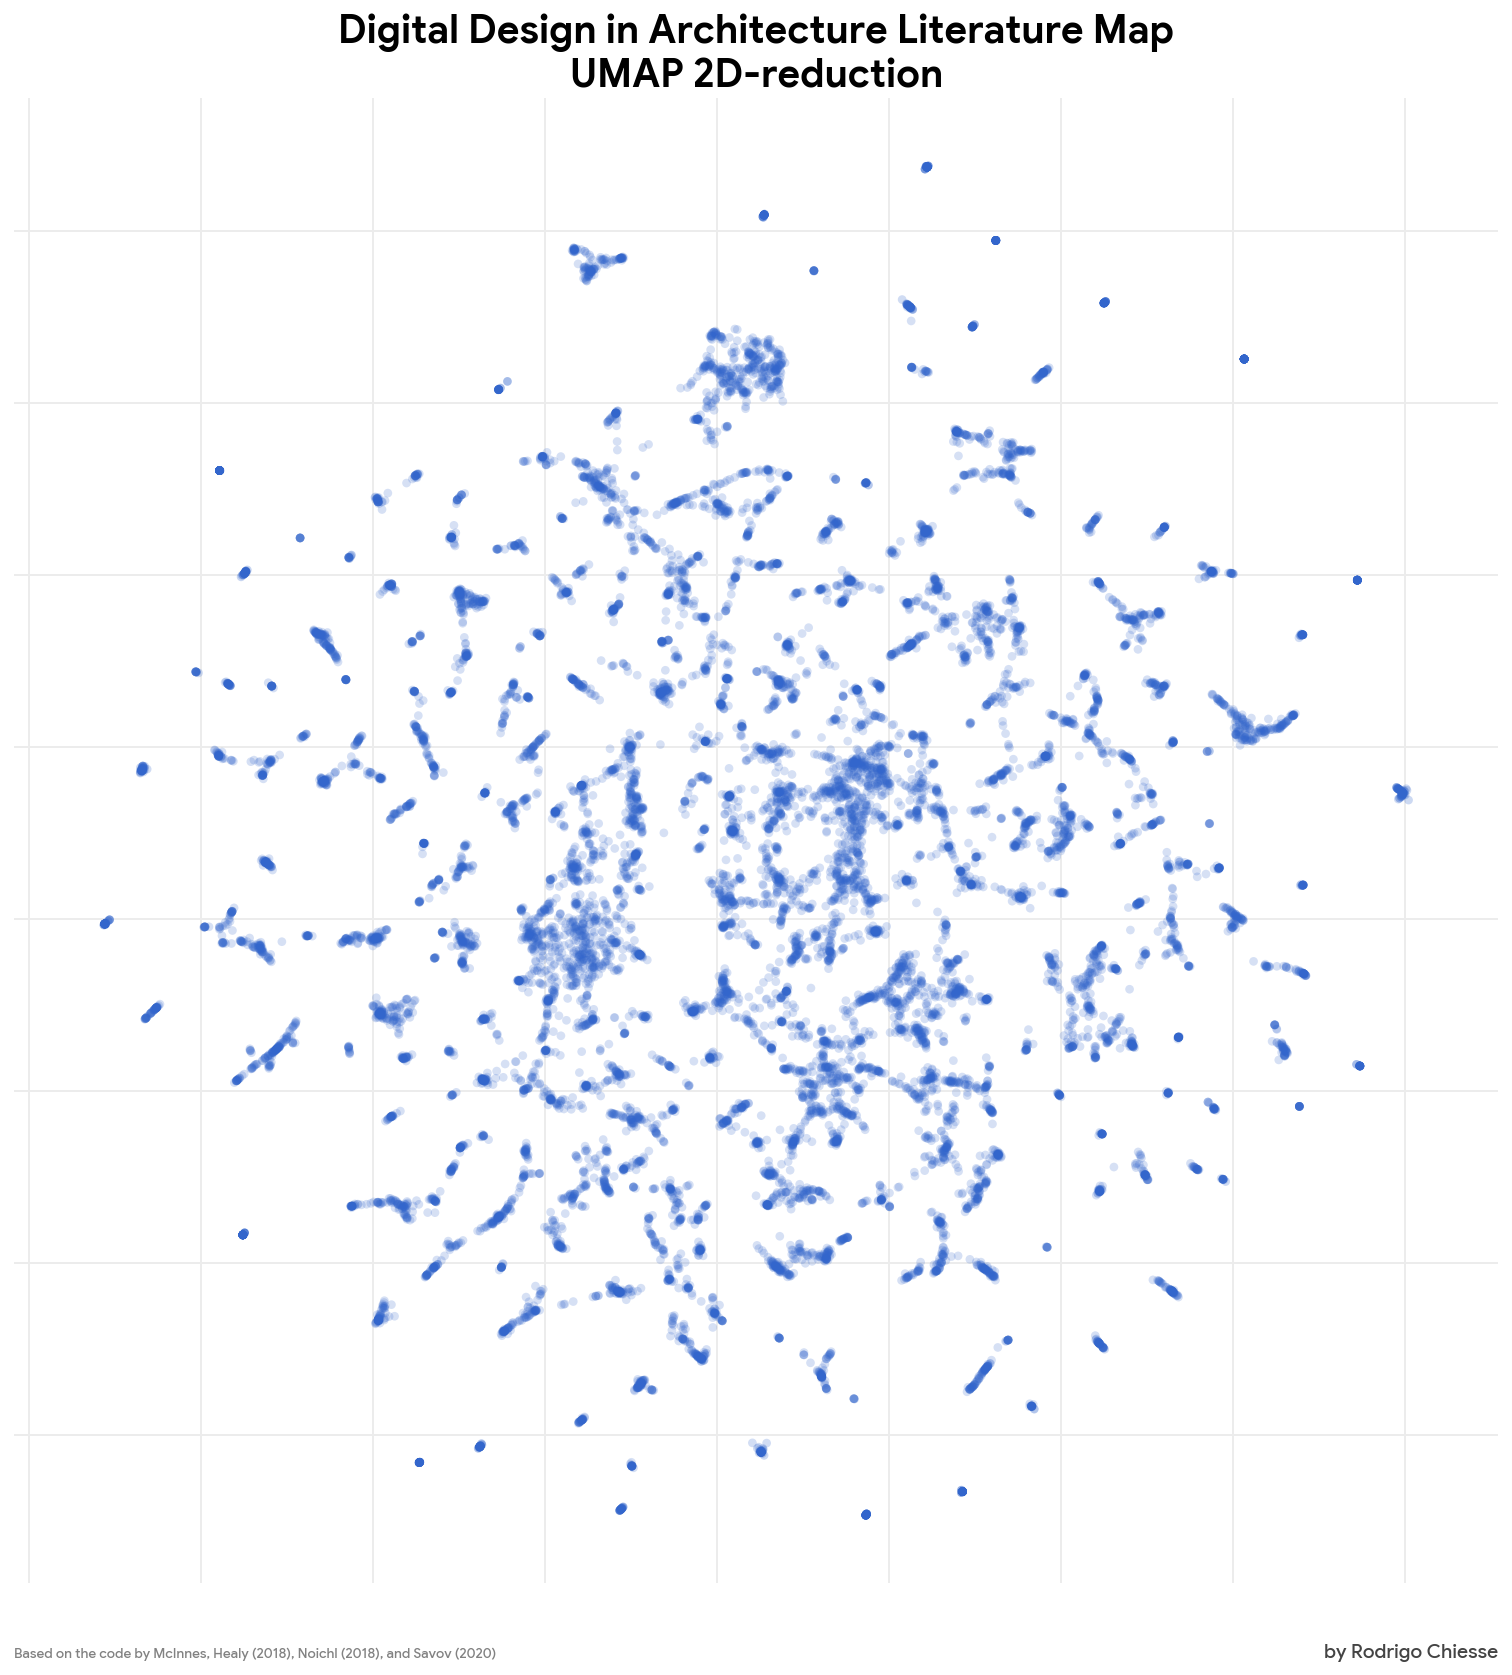

CPU times: total: 1.58 s
Wall time: 1.58 s


In [22]:
%%time
# -- Calculates Density
# -- Stack x and y coordinates to feed into the KDE function
xy = np.vstack([embedding['x'], embedding['y']])
kde = gaussian_kde(xy)
embedding['density'] = kde(xy)

# -- Calculates alpha (1/density)
inv_density = 1 / embedding['density']
# -- Matplotlib requires: 0 <= alpha <= 1
# -- Normalises the inverse density so points don't disappear entirely or throw errors
alpha_scaled = (inv_density - inv_density.min()) / (inv_density.max() - inv_density.min())
# -- Applies a floor (0.1) so the densest points are still faintly visible
alpha_scaled = np.clip(alpha_scaled, 0.2, 1.0)

# -- Sets up the Plot Canvas
fig, ax = plt.subplots(figsize=(12,12), dpi=140)

# -- Sets background colour
bg_colour = 'white'
fig.patch.set_facecolor(bg_colour)
ax.set_facecolor(bg_colour)

# -- Plots the Points
ax.scatter(
    embedding['x'], 
    embedding['y'], 
    c='#3366cc',        # The marker colors
    s=20,               # The marker size (in points squared)
    alpha=alpha_scaled, # Replaces alpha = 1/density
    edgecolors='none'   # solid plotted points without borders/edges
)

# -- Finds the true edges of the data
x_min, x_max = embedding['x'].min(), embedding['x'].max()
y_min, y_max = embedding['y'].min(), embedding['y'].max()

# -- Finds the center point of both axes
x_center = (x_max + x_min) / 2
y_center = (y_max + y_min) / 2

# -- Determines which direction is the widest/tallest stretch
max_span = max(x_max - x_min, y_max - y_min)

# -- Adds a buffer to the maximum span
buffer = max_span * 0.05
half_span = (max_span / 2) + buffer

# -- Applies the exact same span to both axes, centered on our data
ax.set_xlim(x_center - half_span, x_center + half_span)
ax.set_ylim(y_center - half_span, y_center + half_span)

# -- Locks the physical aspect ratio of the plot box
ax.set_aspect('equal', adjustable='box')

# -- Generates the grid lines
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
ax.yaxis.set_major_locator(plt.MaxNLocator(10))

# -- Removes the text of the axes
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_xlabel("")
ax.set_ylabel("")

# -- Styling
# -- Major gridlines light grey, minor blank
ax.grid(which='major', color='#ececec', linestyle='-', linewidth=1)
ax.grid(which='minor', color='none')
ax.set_axisbelow(True) # Puts the grid behind the points
# -- Removes ticks
ax.tick_params(axis='both', which='both', tick1On=False, tick2On=False)

# -- Remove outer borders
for spine in ax.spines.values():
    spine.set_visible(False)

# -- Titles and Captions
# -- Main title
plt.title("Digital Design in Architecture Literature Map\nUMAP 2D-reduction", fontsize=20, fontweight='bold')

# -- Subtitle
plt.text(0, -0.05, "Based on the code by McInnes, Healy (2018), Noichl (2018), and Savov (2020)", 
         fontsize=7, color='#828282', ha='left', transform=ax.transAxes)

# -- Caption
plt.text(1, -0.05, "by Rodrigo Chiesse", 
         fontsize=10, color='#444444', ha='right', transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [23]:
drc.head(1)

,id,year,title,keywords,abstract,journal,AU,Z9,citedAU,citeString,citedDOI
0,WOS:000183530900010,2003,Advances in visual diversity and entropy,MAGICAL NUMBER 7|MINUS 2|COMPLEXITY|URBAN|INFO...,visual diversity is an important component of ...,ENVIRONMENT AND PLANNING B-PLANNING & DESIGN,"Stamps, AE III",72,"[Pyron B, Wohlwill Jf, Duerksen Cj, Krampen Ma...","[Stamps A. E., 2002, HDB ENV PSYCHOL, P222, VI...","[10.1016/c2013-0-10517-x, 10.1080/002213002096..."


---
### HDBSCAN Clustering

In [24]:
%%time
print("Starting HDBSCAN clustering...")

try:
    drc = drc.drop('cluster',axis=1)
except KeyError:
    pass

# -- HDBSCAN finds dense regions of points and groups them into clusters.
# -- min_cluster_size: The absolute minimum number of papers required to form a cluster.
#                      If set to 10, a group of 9 highly related papers on a specific topic 
#                     (like a niche automated hybrid construction method) will be marked as "noise" (-1).
# -- min_samples:  This parameter controls how conservative the clustering is by defining how dense
#                  a neighborhood of points must be to be considered a core part of a cluster.
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=140, 
    min_samples=70,
    gen_min_span_tree=True
)

# -- Fit HDBSCAN on the UMAP coordinates (not the raw count matrix)
cluster_labels = clusterer.fit_predict(embedding)

# -- Resets the drc index to make sure it aligns with the embedding rows
drc = drc.reset_index(drop=True)

# -- Extracts and assigns the coordinates from our 'embedding' DataFrame
drc['x'] = embedding['x']
drc['y'] = embedding['y']

# -- Assigns the cluster labels and alpha
drc['cluster'] = cluster_labels
drc['alpha'] = alpha_scaled
# -----------------------------------------------------------------

# -- Let's see how many clusters we found
num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
num_noise = list(cluster_labels).count(-1)

print(f"HDBSCAN complete.")
print(f"Found {num_clusters} distinct clusters.")
print(f"Papers classified as noise/outliers: {num_noise} out of {len(drc)}")

XCLUST = clusterer.labels_
clusternum = len(set( clusterer.labels_))-1

dfclust = pd.DataFrame(XCLUST)
dfclust.columns = ['cluster']

# -- Preview the updated DataFrame
#drc[['title', 'x', 'y', 'cluster']].head()

Starting HDBSCAN clustering...
HDBSCAN complete.
Found 18 distinct clusters.
Papers classified as noise/outliers: 7660 out of 15379
CPU times: total: 219 ms
Wall time: 218 ms


---
MAKING GRAPHIC

In [25]:
%%time
size_plot = drc['Z9']

mean = size_plot.mean()
sigma = size_plot.std()

bin_edges = [
    -np.inf, 
    mean - 1.5 * sigma, 
    mean - 0.5 * sigma, 
    mean + 0.5 * sigma, 
    mean + 2.0 * sigma,
    mean + 10.0 * sigma,
    np.inf
]

sd_labels_map = {
    '0': '< -1.5 σ (Very Small)',
    '1': '-1.5σ to -0.5σ (Small)',
    '2': 'Within 0.5σ (Average)',
    '3': '0.5σ to 2.0σ (Large)',
    '4': '2σ to 10σ (Very Large)',
    '5': '> 10σ (Extreme)'
}

grouped_sizes = pd.cut(size_plot, bins=bin_edges, labels=False)

# -- Count items per bin and print the distribution
print(f"---    mean: {mean:.0f}  ||  sigma: {sigma:.0f}    ---")
print( "--- Distribution of Items per Bin ---" )
bin_counts = grouped_sizes.value_counts().sort_index()
for bin_idx, count in bin_counts.items():
    # Use the map to print the friendly label alongside the count
    label_text = sd_labels_map.get(str(bin_idx), f"Bin {bin_idx}")
    print(f"{label_text:<23} : {count:5} items")

# -- Filters out noise elements sizes
cluster_mask = drc['cluster'] != -1
noise_mask = drc['cluster'] == -1

size_list = [40,120,240, 480]

---    mean: 38  ||  sigma: 83    ---
--- Distribution of Items per Bin ---
Within 0.5σ (Average)   : 13418 items
0.5σ to 2.0σ (Large)    :  1582 items
2σ to 10σ (Very Large)  :   360 items
> 10σ (Extreme)         :    19 items
CPU times: total: 0 ns
Wall time: 2 ms


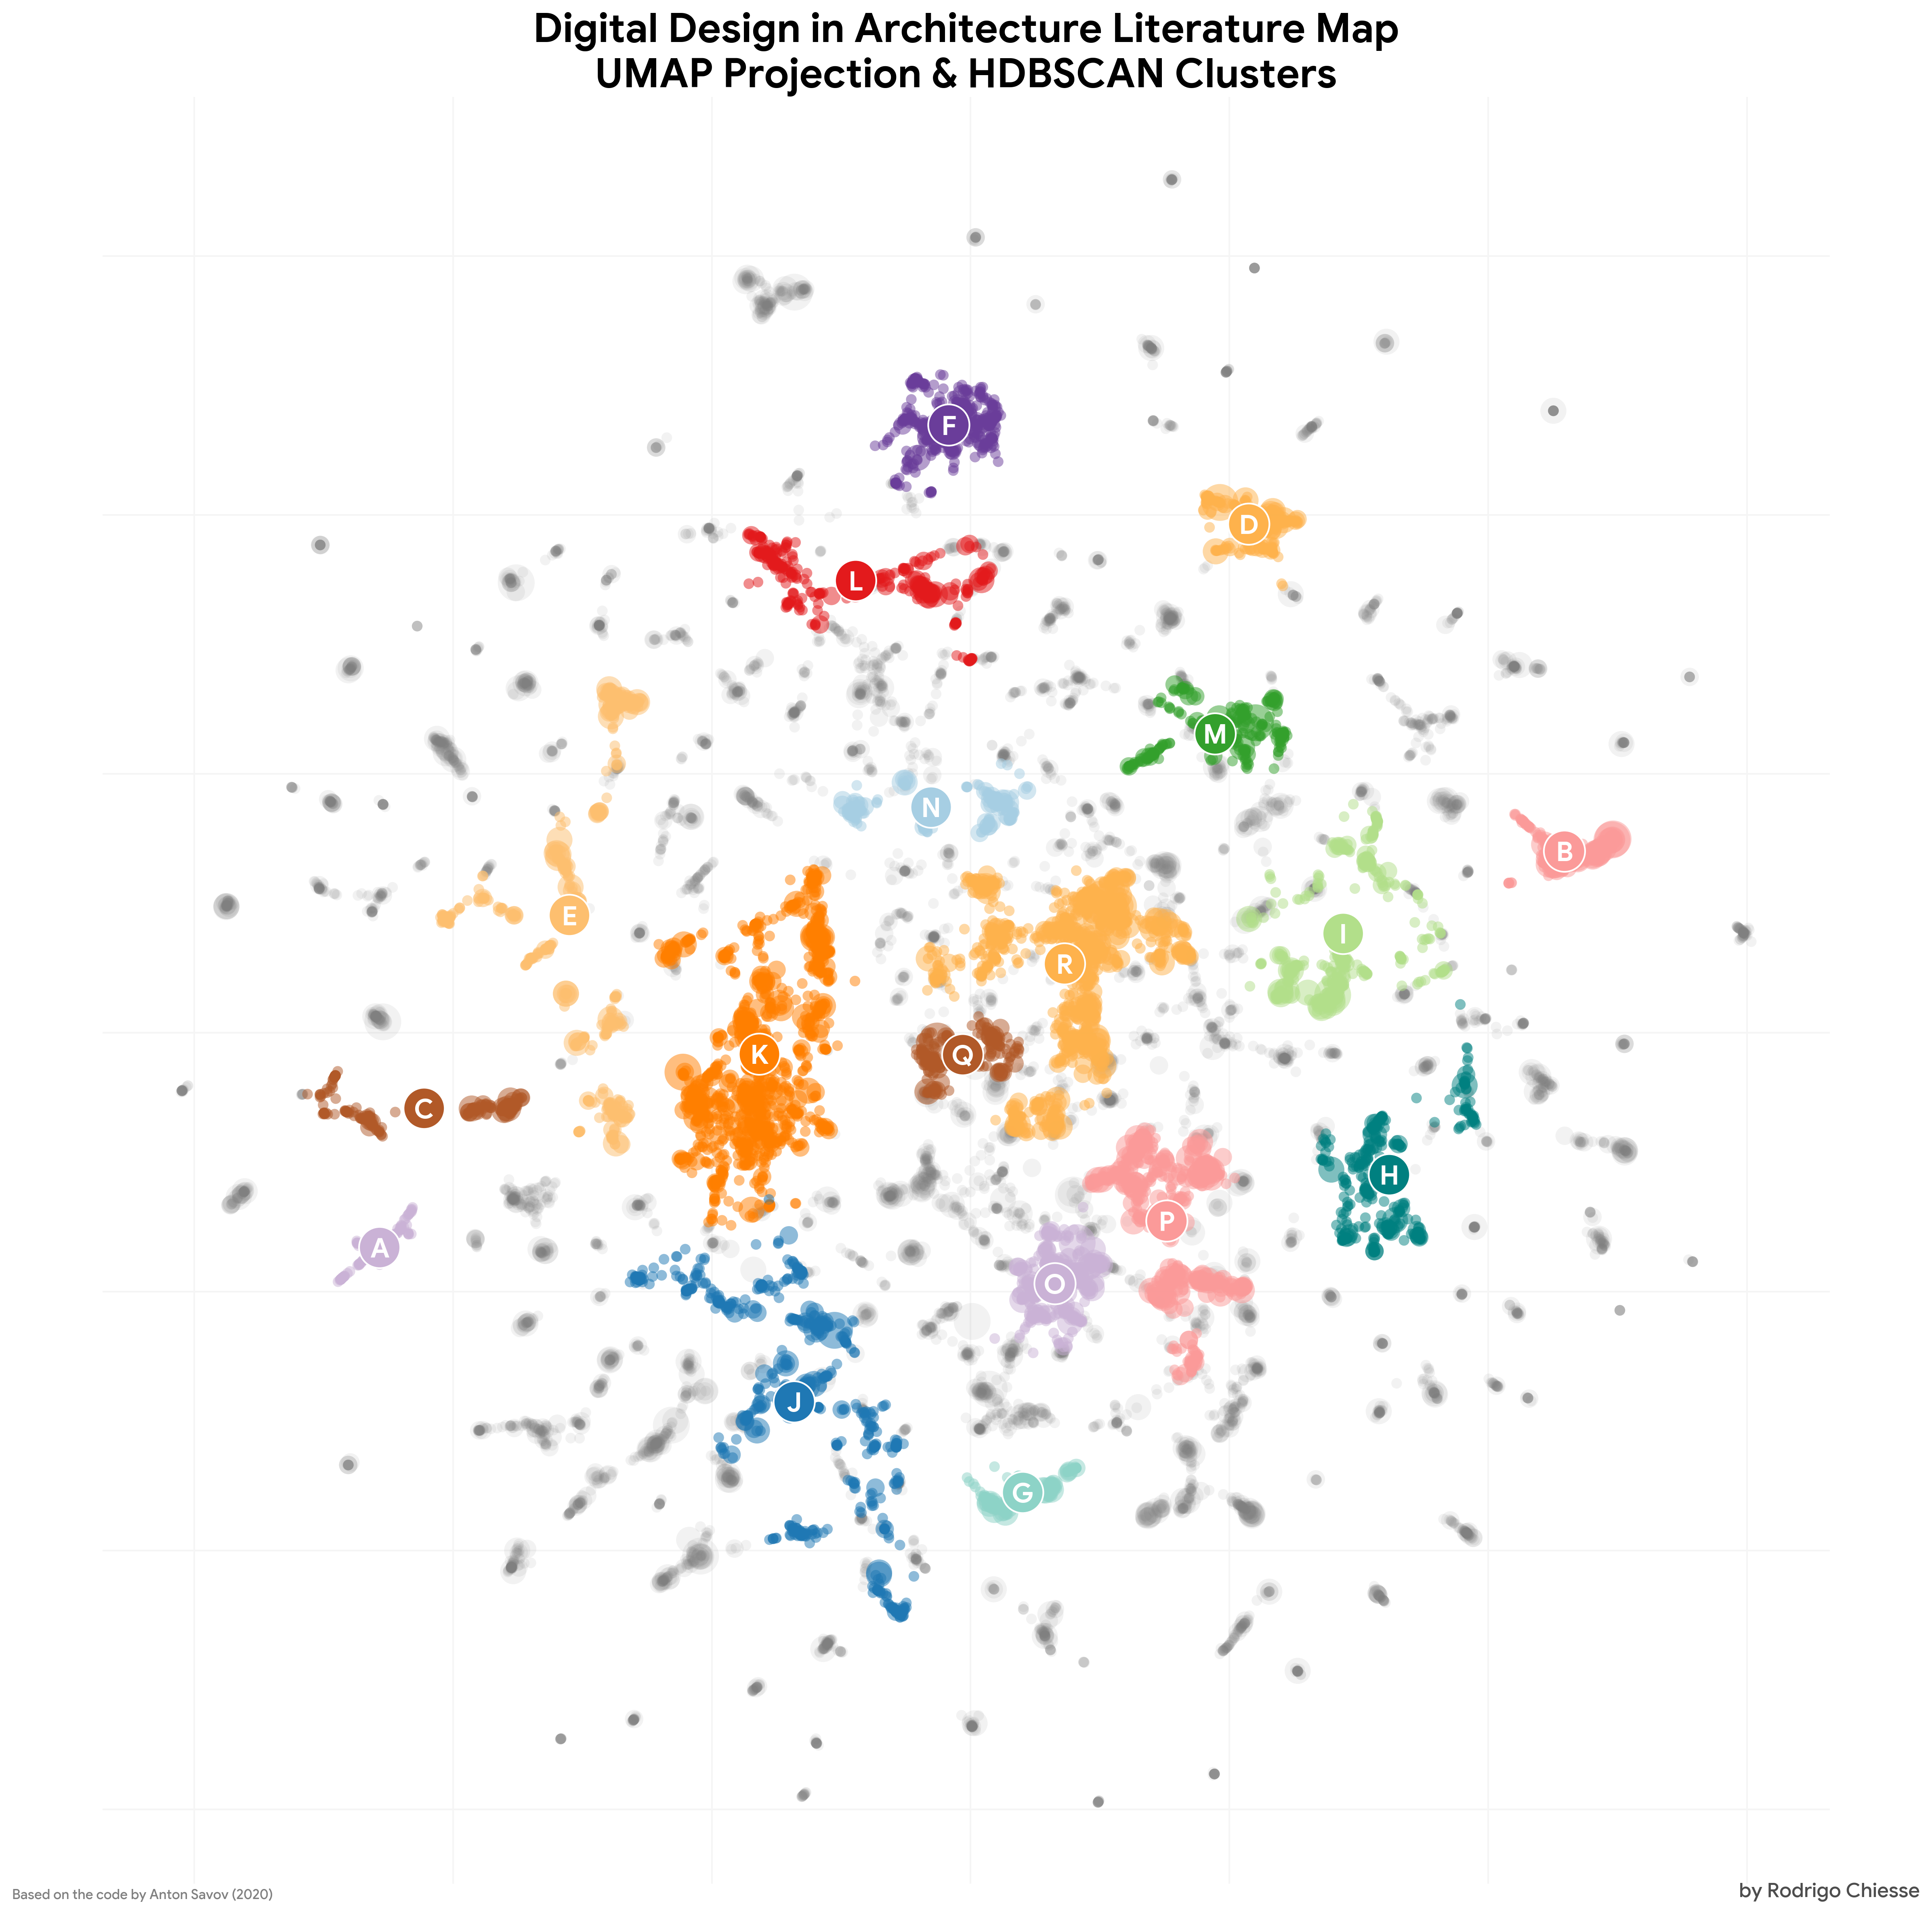

CPU times: total: 672 ms
Wall time: 663 ms


In [26]:
%%time
plt.close('all')

def cm_to_in(number):
    inches = number / 2.54
    return inches
    
# A 16-color palette
palette_high_contrast = ['#CAB2D6', '#FB9A99',
                         '#B15928', '#FEB24C',
                         '#FDBF6F', '#6A3D9A',
                         '#8DD3C7', '#008080',
                         '#B2DF8A', '#1F78B4',
                         '#FF7F00', '#E31A1C',
                         '#33A02C', '#A6CEE3']

palette_high_contrast = (palette_high_contrast * (num_clusters // len(palette_high_contrast) + 1))[:num_clusters]
#palette_high_contrast = palette_high_contrast[0:num_clusters]

# Apply to seaborn
sns.set_palette(palette_high_contrast)

# -- Static visualisation (to print on a square cut A2 sheet with 1 cm margin = 40 cm)
fig_cluster, ax_cluster = plt.subplots(figsize=(cm_to_in(40), cm_to_in(40)), dpi=300, layout="tight")
ax_cluster.set_aspect('equal', adjustable='box')

# -- Sets background colour
bg_color = 'white'
fig_cluster.patch.set_facecolor(bg_color)
ax_cluster.set_facecolor(bg_color)

# -- Plots the noise points separately in a light grey so they don't distract
sns.scatterplot(
    data=drc[noise_mask],
    x='x', y='y',
    color='grey',
    legend=False,
    alpha=0.1, # -- adjust if necessary,
    edgecolors='none',
    ax=ax_cluster,
    size=grouped_sizes[noise_mask],
    sizes=size_list
)

# -- We can filter out noise (-1) for a cleaner color palette, or keep it to see outliers
# -- We will use a distinct color palette for the recognized clusters
sns.scatterplot(
    data=drc[cluster_mask],
    x='x', y='y',
    hue='cluster',
    palette=palette_high_contrast,
    legend=False,
    alpha=1.0,
    edgecolors='none',
    ax=ax_cluster,
    size=grouped_sizes[cluster_mask],
    sizes=size_list
)

# -- Sets individual points opacity for non-noise elements
#ax_cluster.collections[-1].set_alpha(drc[cluster_mask]['alpha']) # -- Alphas based on what we calculated previously
ax_cluster.collections[-1].set_alpha(0.5)                        # -- Same alpha for all points

# -- Function to convert integer index to letters (0->A, 25->Z, 26->AA)
def index_to_letter(cluster_id):
    if cluster_id == -1:
        return 'Noise'  # -- Labels noise
    
    result = ""
    while cluster_id >= 0:
        result = chr(65 + (cluster_id % 26)) + result
        cluster_id = (cluster_id // 26) - 1
    return result

# -- Creates a new column with the letter designations
drc['cluster_letter'] = drc['cluster'].apply(index_to_letter)

# -- Calculates the geometric centers
# Group by cluster and compute the mean for X and Y coordinates
centroids = drc[cluster_mask].groupby('cluster_letter')[['x', 'y']].mean()
#centroids = drc[cluster_mask].groupby('cluster')[['x', 'y']].mean()

# Lets plot the circles first, then overlay text
letter_circles = plt.scatter(
    centroids['x'], 
    centroids['y'], 
    s=600,
    color=palette_high_contrast, 
    alpha=1,
    edgecolor='white',
    zorder=4              # Sit closely on top of data points
)

# -- Dictionary to hold our text objects
cluster_labels = {}

# -- Overlays the cluster indices at the coordinates of the centers
for cluster_letter, row in centroids.iterrows():
    cluster_labels[cluster_letter] = plt.text(
        x=row['x'], 
        y=row['y'], 
        s=cluster_letter,
        color='white',
        fontsize=16,
        weight='bold',
        ha='center',
        va='center_baseline',
        zorder=5
    )

# -- Remove outer borders
for spine in ax_cluster.spines.values():
    spine.set_visible(False)
    
# -- Grid lines
# -- Major gridlines light grey, minor blank
ax_cluster.grid(which='major', color='#f5f5f5', linestyle='-', linewidth=1)
#ax_cluster.grid(which='minor', color='#f5f5f5', linestyle='-', linewidth=1)
ax_cluster.set_axisbelow(True) # Puts the grid behind the points

# -- Removes ticks and tick labels
ax_cluster.tick_params(axis='both', which='both', tick1On=False, tick2On=False)
ax_cluster.set_xticklabels([])
ax_cluster.set_yticklabels([])

# -- Removes the text of the axes
ax_cluster.set_xlabel("")
ax_cluster.set_ylabel("")

# -- Sets text elements
# -- Get the legend labels
handles, labels = ax_cluster.get_legend_handles_labels()
cleaned_labels = []
# -- Title
ax_cluster.set_title('Digital Design in Architecture Literature Map\nUMAP Projection & HDBSCAN Clusters', weight='bold', fontsize=24)
# -- Legend
#ax_cluster.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', title='Legend', frameon=False)
# -- Subtitle
fig_cluster.text(0, 0, "Based on the code by Anton Savov (2020)", fontsize=8, color='0.5', ha='left', va='bottom')
fig_cluster.text(1, 0, "by Rodrigo Chiesse", fontsize=12, color='0.3', ha='right', va='bottom')

# -- Display graphic
plt.show()

---
### TREE OF CLUSTER SIMILARITY

In [27]:
%%time
tree = clusterer.condensed_tree_.to_pandas()
cluster_tree = tree[tree.child_size > 1]

cluster_gradient = LinearSegmentedColormap.from_list( "", ["#FCC696","#F88F79","#DA6688","#AB5596","#7D4495","#4D3E71"] )

#get the node ids of the clusters
chosen_clusters = clusterer.condensed_tree_._select_clusters()

#get the condensed cluster tree
tree = clusterer.condensed_tree_.to_numpy()
cluster_tree = [x for x in tree if x[3]>1]

my_cluster_colours = palette_high_contrast[0:num_clusters]

CPU times: total: 15.6 ms
Wall time: 7.49 ms


In [28]:
%%time
parent_nodes = [x[0] for x in cluster_tree]

links = []
cluster_nodes =[]
nodes = []
removed_parent_nodes = []

first_node = min(parent_nodes)
node = {'id': first_node, 'title': 'All articles' }
nodes.append(node)

for edge in cluster_tree:
    if edge[0] in chosen_clusters or edge[0] in removed_parent_nodes:
         #filter out leaves that didn't get selected as a cluster
        removed_parent_nodes.append(edge[1])
    else:
        if edge[1] in chosen_clusters:
            #this is a cluster leaf so set label, color, etc
            cluster_id = chosen_clusters.index(edge[1])
            cluster_label = "cluster " + str(cluster_id)
            color = my_cluster_colours[cluster_id]
            cluster_nodes.append(edge[1])
            node = {'id': edge[1], 'title': cluster_label, 'style': 'process' }
        else:
            #this is a branch so use default color and remove label
            color = '#16457D' #"#bfc4c6"
            node = {'id': edge[1], 'title': '' }
        nodes.append(node)
        link = {
            'source':edge[0],
            'target':edge[1],
            'value':edge[3],
            'color':color
        }
        links.append(link)

#use the rank_sets to place all cluster leafs on the same line
rank_sets = [
    { 'type': 'same', 'nodes': cluster_nodes }
]

sankey = SankeyWidget(links=links, nodes=nodes, layout = Layout(width="1920", height="300")).auto_save_svg('exports/cluster_tree.svg')
sankey

CPU times: total: 0 ns
Wall time: 4.13 ms


SankeyWidget(layout=Layout(height='300', width='1920'), links=[{'source': np.int64(15379), 'target': np.int64(…

---
### CATEGORIZING CLUSTERS

In [29]:
# -- Preview DataFrame
#drc.head(1)

In [30]:
%%time
#load up the UK to US spelling dictionary
uk2us = {}
with open('data/uk-to-us-dict.csv', 'r') as csvfile:
    spamreader = csv.reader(csvfile, delimiter=',')
    for row in spamreader:
        ukword = row[0].replace(" ", "")
        usword = row[1].replace(" ", "")
        uk2us[ukword] = usword

CPU times: total: 0 ns
Wall time: 3.26 ms


In [31]:
#kick out common abstract words of no importance
removeWords = ['|','paper','argue','account','theory',
                'elsevier','reserved','rights',
                'used','use','new','using',
                'copyright','published','article',
                'articles','open access', 'cc',
                'license','authors ','author'
              ]

In [32]:
%%time
def compile_replacer(replace_dict):
    """
    Creates a single-pass regex replacement function.
    Sorts keys by length to prevent partial matches (e.g. matching 'car' inside 'carpet' 
    if word boundaries weren't strictly enforced, though \b handles this safely here).
    """
    sorted_keys = sorted(replace_dict.keys(), key=len, reverse=True)
    
    # Compile one giant regex: \b(word1|word2|word3)\b
    pattern = re.compile(r'\b(' + '|'.join(map(re.escape, sorted_keys)) + r')\b')
    
    # This function looks up the matched UK word and returns the US word
    def replacer(match):
        return replace_dict[match.group(1)]
    
    # Return a callable that applies this logic
    return lambda text: pattern.sub(replacer, text)


def buildTextBags(drcval, replacedict, removelist, tag, clean=True):
    fullstrsl = []
    
    # 1. Compile regexes ONCE outside of any loops
    remove_pattern = re.compile(r'\b(?:' + '|'.join(map(re.escape, removelist)) + r')\b')
    fast_replace = compile_replacer(replacedict)
    
    # 2. Optimize Pandas grouping
    # Group by cluster and join all strings with a semicolon in one fast, vectorized operation
    # Note: If your clusters are missing numbers (e.g., cluster 2 is empty), groupby will skip it.
    grouped_texts = drcval.groupby('cluster')[tag].apply(lambda x: ';'.join(x.astype(str)))
    
    # 3. Apply the regex cleaning to each joined text bag
    for textBag in grouped_texts:
        if clean:
            textBag = remove_pattern.sub(" ", textBag)
            
        # Apply the fast, single-pass dictionary replacement
        textBag = fast_replace(textBag)
        
        fullstrsl.append(textBag)
        
    return fullstrsl

# Build the bags
clusterTextBagsTitles = buildTextBags(drc, uk2us, removeWords, 'title')
clusterTextBagsAbstracts = buildTextBags(drc, uk2us, removeWords, 'abstract')

CPU times: total: 29.1 s
Wall time: 30.2 s


In [33]:
%%time
#check if a string searchfor exists in 'searchin' only as a whole word/phrase
def string_found(searchfor, searchin):
    return re.search(r'\b%s\b' % (re.escape(searchfor)), searchin) is not None

#if a phrase is found in a longer phrase reduce its score with the score of hte longer phrase
#exclude if true the word score is set to 0 if exclude is false then the longer word score is subtracted from short word score
def accountScores(longphrasescores, shortphrasescores, exclude=True):
    newscores =[]
    for phrase in shortphrasescores:
        newphraseScore = [phrase[0],phrase[1]]
        for longphrase in longphrasescores:
            #if phrase is found in longphrase subtract scores
            #pat = re.compile(r"\b%s\b" % re.escape(phrase[0]))
            #print(phrase[0])
            
            if string_found(phrase[0], longphrase[0]):
                if exclude:
                    newphraseScore[1] = 0
                else:                      
                    newphraseScore[1] = phrase[1]-longphrase[1]
        newscores.append(newphraseScore)
    return newscores

#this def below is not needed anymore
def accountScoreClusters(longscores, shortscores):
    counter =0
    newclusterscores =[]
    for cluster in shortscores:
        newclusterscores.append(accountScores(longscores[counter],cluster))
        counter +=1
    return newclusterscores

CPU times: total: 0 ns
Wall time: 0 ns


In [34]:
%%time
def rankWords(textBag, phrase=1, n=10, treshold=10, longphrasescores=None):
    vec = CountVectorizer(stop_words='english', ngram_range=(phrase, phrase))
    X = vec.fit_transform(textBag)
    feature_names = vec.get_feature_names_out()
    
    # REMOVED: pd.DataFrame(X.toarray()...) - It wasted massive amounts of RAM and wasn't used.
    
    fullscore = []
    
    # Iterate over the number of rows (clusters) directly from the matrix shape
    for x in range(X.shape[0]):
        # Extract the dense array for *only this single row*
        row_array = X[x, :].toarray().ravel()
        
        # Fast extraction: Get indices of the top 60 highest scores without sorting everything
        # np.argpartition is significantly faster than sorting the entire vocabulary
        if len(row_array) > 60:
            top_60_idx = np.argpartition(row_array, -60)[-60:]
            # Sort only those top 60 indices in descending order
            top_60_idx = top_60_idx[np.argsort(row_array[top_60_idx])[::-1]]
        else:
            top_60_idx = np.argsort(row_array)[::-1]
        
        # Build the initial list of (word, score) for ONLY the top 60 items
        accountedScores = [(feature_names[i], row_array[i]) for i in top_60_idx]
        
        # Apply deductions if long phrases exist
        if longphrasescores is not None:            
            for longphrasescore in longphrasescores:
                accountedScores = accountScores(longphrasescore[0][x], accountedScores, longphrasescore[1])
            
            # Resort after deductions
            accountedScores.sort(key=lambda x: x[1], reverse=True)
        
        # Take the top 'n' scores
        myscores = accountedScores[:n]
        
        # Filter by threshold (using list comprehension for speed)
        # Keeps the item if it beats the threshold OR if it's the very first item (counter == 0 logic)
        scorelist = [[s[0], s[1]] for i, s in enumerate(myscores) if s[1] > treshold or i == 0]
        
        fullscore.append(scorelist)
        
    return fullscore


def addClusterScores(score1, score2):
    # Replaces the nested loops with a highly optimized, one-line C-level zip mapping
    return [c1 + c2 for c1, c2 in zip(score1, score2)]

CPU times: total: 0 ns
Wall time: 0 ns


In [35]:
%%time

print("TOP 5 TRIGRAMS ABSTRACTS")
trigramScoreAbstracts = rankWords(clusterTextBagsAbstracts,phrase=3)
display(pd.DataFrame(trigramScoreAbstracts).transpose().head())

print("TOP 5 TRIGRAMS TITLES")
trigramScoreTitles = rankWords(clusterTextBagsTitles,phrase=3,longphrasescores=[[trigramScoreAbstracts,True]])
display(pd.DataFrame(trigramScoreTitles).transpose().head())


print("TOP 5 TRIGRAMS COMBINED")
trigrams = addClusterScores(trigramScoreAbstracts,trigramScoreTitles)
display(pd.DataFrame(trigrams).transpose().head())

TOP 5 TRIGRAMS ABSTRACTS


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,"[building information modeling, 325]","[leonardo da vinci, 3]","[concrete printing dcp, 23]","[finite element analysis, 11]","[space syntax analysis, 10]","[synthetic point clouds, 26]","[shape grammar interpreter, 21]","[text data mining, 8]","[constructive solid geometry, 9]","[augmented reality ar, 56]","[architectural design process, 19]","[biologically inspired design, 26]","[tool path generation, 34]","[early design stage, 15]","[building information modeling, 6]","[point cloud data, 55]","[building information modeling, 181]","[natural language processing, 26]","[convolutional neural network, 91]"
1,"[information modeling bim, 257]",None,None,None,None,"[finite element analysis, 25]","[parametric shape grammar, 13]",None,None,"[virtual reality vr, 34]","[planning support systems, 17]","[architectural design process, 19]","[sculptured surface machining, 15]","[building performance simulation, 14]",None,"[building information modeling, 26]","[information modeling bim, 145]","[tunnel boring machine, 24]","[convolutional neural networks, 45]"
2,"[architecture engineering construction, 85]",None,None,None,None,"[point cloud data, 20]","[shape grammar formalism, 13]",None,None,"[building information modeling, 23]","[building information modeling, 15]","[engineering design process, 16]",None,"[nondominated sorting genetic, 12]",None,"[building information models, 24]","[architecture engineering construction, 40]","[boring machine tbm, 19]","[neural network cnn, 44]"
3,"[industry foundation classes, 71]",None,None,None,None,"[point cloud segmentation, 18]","[shape grammar rules, 12]",None,None,"[architecture engineering construction, 23]",None,"[design process design, 16]",None,"[sorting genetic algorithm, 11]",None,"[terrestrial laser scanning, 22]","[industry foundation classes, 31]","[large language models, 18]","[experimental results demonstrate, 38]"
4,"[finite element analysis, 65]",None,None,None,None,"[building information modeling, 18]","[shape grammar interpreters, 11]",None,None,"[information modeling bim, 17]",None,"[conceptual design process, 14]",None,None,None,"[information modeling bim, 19]","[building information models, 30]","[language processing nlp, 17]","[mean average precision, 37]"


TOP 5 TRIGRAMS TITLES


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,"[multi objective optimization, 19]","[pantheon hadrian serapeum, 2]","[3d concrete printing, 25]","[quadrilateral mesh generation, 4]","[world wide web, 2]","[cloud semantic segmentation, 10]","[islamic geometric patterns, 3]","[space virtual reality, 2]","[periodic minimal surfaces, 4]","[immersive virtual reality, 5]","[case based design, 6]","[computer aided design, 5]","[free form surfaces, 8]","[multi objective optimization, 9]","[feature based design, 5]","[3d laser scanning, 7]","[building information modelling, 7]","[multi objective optimization, 8]","[deep learning based, 37]"
1,"[computer aided design, 18]",None,"[3d printed concrete, 13]",None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"[based deep learning, 16]"
2,"[structural health monitoring, 17]",None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"[computer vision based, 14]"
3,"[particle swarm optimization, 17]",None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"[generative adversarial networks, 13]"
4,"[tool path generation, 17]",None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


TOP 5 TRIGRAMS COMBINED


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,"[building information modeling, 325]","[leonardo da vinci, 3]","[concrete printing dcp, 23]","[finite element analysis, 11]","[space syntax analysis, 10]","[synthetic point clouds, 26]","[shape grammar interpreter, 21]","[text data mining, 8]","[constructive solid geometry, 9]","[augmented reality ar, 56]","[architectural design process, 19]","[biologically inspired design, 26]","[tool path generation, 34]","[early design stage, 15]","[building information modeling, 6]","[point cloud data, 55]","[building information modeling, 181]","[natural language processing, 26]","[convolutional neural network, 91]"
1,"[information modeling bim, 257]","[pantheon hadrian serapeum, 2]","[3d concrete printing, 25]","[quadrilateral mesh generation, 4]","[world wide web, 2]","[finite element analysis, 25]","[parametric shape grammar, 13]","[space virtual reality, 2]","[periodic minimal surfaces, 4]","[virtual reality vr, 34]","[planning support systems, 17]","[architectural design process, 19]","[sculptured surface machining, 15]","[building performance simulation, 14]","[feature based design, 5]","[building information modeling, 26]","[information modeling bim, 145]","[tunnel boring machine, 24]","[convolutional neural networks, 45]"
2,"[architecture engineering construction, 85]",None,"[3d printed concrete, 13]",None,None,"[point cloud data, 20]","[shape grammar formalism, 13]",None,None,"[building information modeling, 23]","[building information modeling, 15]","[engineering design process, 16]","[free form surfaces, 8]","[nondominated sorting genetic, 12]",None,"[building information models, 24]","[architecture engineering construction, 40]","[boring machine tbm, 19]","[neural network cnn, 44]"
3,"[industry foundation classes, 71]",None,None,None,None,"[point cloud segmentation, 18]","[shape grammar rules, 12]",None,None,"[architecture engineering construction, 23]","[case based design, 6]","[design process design, 16]",None,"[sorting genetic algorithm, 11]",None,"[terrestrial laser scanning, 22]","[industry foundation classes, 31]","[large language models, 18]","[experimental results demonstrate, 38]"
4,"[finite element analysis, 65]",None,None,None,None,"[building information modeling, 18]","[shape grammar interpreters, 11]",None,None,"[information modeling bim, 17]",None,"[conceptual design process, 14]",None,"[multi objective optimization, 9]",None,"[information modeling bim, 19]","[building information models, 30]","[language processing nlp, 17]","[mean average precision, 37]"


CPU times: total: 4.7 s
Wall time: 5.52 s


In [36]:
%%time
print("TOP 5 BIGRAMS ABSTRACTS")
bigramScoreAbstracts = rankWords(clusterTextBagsAbstracts,phrase=2, n=5,longphrasescores=[[trigrams,False]])
#bigramScoreAbstracts = accountScoreClusters(trigramScoreAbstracts, bigramScoreAbstracts)
display(pd.DataFrame(bigramScoreAbstracts).transpose().head())

print("TOP 5 BIGRAMS TITLES")
bigramScoreTitles = rankWords(clusterTextBagsTitles,phrase=2, n=5,longphrasescores=[[trigrams,False],[bigramScoreAbstracts,True]])
#print(bigramScoreTitles[:10])
#bigramScoreTitles = accountScoreClusters(trigramScoreTitles, bigramScoreTitles)
#print(bigramScoreTitles[:10])
display(pd.DataFrame(bigramScoreTitles).transpose().head())

print("TOP 5 BIGRAMS COMBINED")
bigrams = addClusterScores(bigramScoreAbstracts,bigramScoreTitles)
display(pd.DataFrame(bigrams).transpose().head())

TOP 5 BIGRAMS ABSTRACTS


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,"[case study, 709]","[architectural design, 10]","[additive manufacturing, 55]","[mesh generation, 46]","[space syntax, 61]","[point clouds, 169]","[shape grammar, 210]","[participatory design, 27]","[point cloud, 63]","[virtual reality, 65]","[design process, 119]","[design process, 429]","[tool path, 70]","[design process, 53]","[design process, 34]","[point cloud, 171]","[building information, 244]","[proposed method, 36]","[deep learning, 316]"
1,"[proposed method, 533]",None,"[concrete printing, 34]","[finite element, 20]","[urban design, 18]","[topology optimization, 136]","[shape grammars, 188]","[design process, 27]","[point clouds, 47]","[design process, 42]","[architectural design, 119]","[conceptual design, 138]","[computational design, 49]","[case study, 42]","[proposed method, 27]","[point clouds, 156]","[construction industry, 92]","[deep learning, 34]","[proposed method, 231]"
2,"[building information, 467]",None,"[construction industry, 34]","[mesh adaptation, 19]","[case study, 16]","[point cloud, 100]","[generative design, 43]","[case study, 18]","[boolean operations, 30]","[proposed method, 39]","[case study, 71]","[design research, 115]","[tool paths, 45]","[architectural design, 36]","[cad models, 25]","[laser scanning, 76]","[case study, 78]","[neural network, 28]","[machine learning, 148]"
3,"[design process, 460]",None,"[digital fabrication, 25]","[tetrahedral mesh, 18]","[spatial configurations, 16]","[proposed method, 74]","[design process, 41]","[design research, 18]","[experimental results, 29]","[augmented reality, 32]","[digital fabrication, 41]","[case study, 108]","[digital fabrication, 36]","[energy performance, 32]","[process planning, 23]","[proposed method, 60]","[construction projects, 65]","[machine learning, 28]","[crack detection, 136]"
4,"[construction industry, 339]",None,"[future research, 23]","[mesh quality, 17]","[spatial configuration, 15]","[deep learning, 55]","[architectural design, 39]","[virtual reality, 11]","[normal estimation, 27]","[case study, 27]","[design processes, 38]","[engineering design, 105]","[robotic fabrication, 28]","[design optimization, 31]","[case study, 21]","[building information, 43]","[construction sites, 60]","[tunnel boring, 25]","[construction sites, 133]"


TOP 5 BIGRAMS TITLES


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,"[real time, 112]","[sixteenth century, 3]","[3d printing, 39]","[spatial planning, 10]","[agent based, 5]","[semantic segmentation, 23]","[grammar based, 10]","[product design, 5]","[solid modeling, 9]","[built environment, 8]","[design studio, 13]","[design thinking, 20]","[axis machining, 16]","[multi objective, 12]","[computer aided, 6]","[3d point, 10]","[bim based, 32]","[real time, 15]","[real time, 43]"
1,"[construction projects, 85]",None,"[3d printed, 16]",None,None,"[additive manufacturing, 14]",None,None,None,None,"[collaborative design, 13]","[architectural design, 19]",None,None,None,None,"[real time, 25]","[construction safety, 11]","[vision based, 42]"
2,"[architectural design, 68]",None,None,None,None,"[agent based, 13]",None,None,None,None,"[case based, 12]","[idea generation, 18]",None,None,None,None,"[building design, 11]",None,"[construction workers, 38]"
3,"[machine learning, 68]",None,None,None,None,None,None,None,None,None,"[generative design, 12]","[collaborative design, 18]",None,None,None,None,None,None,"[crack segmentation, 36]"
4,"[digital twin, 65]",None,None,None,None,None,None,None,None,None,"[agent based, 12]","[design education, 17]",None,None,None,None,None,None,"[computer vision, 29]"


TOP 5 BIGRAMS COMBINED


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,"[case study, 709]","[architectural design, 10]","[additive manufacturing, 55]","[mesh generation, 46]","[space syntax, 61]","[point clouds, 169]","[shape grammar, 210]","[participatory design, 27]","[point cloud, 63]","[virtual reality, 65]","[design process, 119]","[design process, 429]","[tool path, 70]","[design process, 53]","[design process, 34]","[point cloud, 171]","[building information, 244]","[proposed method, 36]","[deep learning, 316]"
1,"[proposed method, 533]","[sixteenth century, 3]","[concrete printing, 34]","[finite element, 20]","[urban design, 18]","[topology optimization, 136]","[shape grammars, 188]","[design process, 27]","[point clouds, 47]","[design process, 42]","[architectural design, 119]","[conceptual design, 138]","[computational design, 49]","[case study, 42]","[proposed method, 27]","[point clouds, 156]","[construction industry, 92]","[deep learning, 34]","[proposed method, 231]"
2,"[building information, 467]",None,"[construction industry, 34]","[mesh adaptation, 19]","[case study, 16]","[point cloud, 100]","[generative design, 43]","[case study, 18]","[boolean operations, 30]","[proposed method, 39]","[case study, 71]","[design research, 115]","[tool paths, 45]","[architectural design, 36]","[cad models, 25]","[laser scanning, 76]","[case study, 78]","[neural network, 28]","[machine learning, 148]"
3,"[design process, 460]",None,"[digital fabrication, 25]","[tetrahedral mesh, 18]","[spatial configurations, 16]","[proposed method, 74]","[design process, 41]","[design research, 18]","[experimental results, 29]","[augmented reality, 32]","[digital fabrication, 41]","[case study, 108]","[digital fabrication, 36]","[energy performance, 32]","[process planning, 23]","[proposed method, 60]","[construction projects, 65]","[machine learning, 28]","[crack detection, 136]"
4,"[construction industry, 339]",None,"[future research, 23]","[mesh quality, 17]","[spatial configuration, 15]","[deep learning, 55]","[architectural design, 39]","[virtual reality, 11]","[normal estimation, 27]","[case study, 27]","[design processes, 38]","[engineering design, 105]","[robotic fabrication, 28]","[design optimization, 31]","[case study, 21]","[building information, 43]","[construction sites, 60]","[tunnel boring, 25]","[construction sites, 133]"


CPU times: total: 3.53 s
Wall time: 4.05 s


In [37]:
%%time
print("TOP 5 WORDS IN ABSTRACTS")
wordScoreAbstracts = rankWords(clusterTextBagsAbstracts,phrase=1, n=20, longphrasescores=[[trigrams,False],[bigrams,False]])
display(pd.DataFrame(wordScoreAbstracts).transpose().head())

print("TOP 5 WORDS IN TITLES")
wordScoreTitles = rankWords(clusterTextBagsTitles,phrase=1, n=20, longphrasescores=[[trigrams,False],[bigrams,False],[wordScoreAbstracts,True]])
display(pd.DataFrame(wordScoreTitles).transpose().head())

words = addClusterScores(wordScoreAbstracts,wordScoreTitles)
#display(pd.DataFrame(words).transpose())

TOP 5 WORDS IN ABSTRACTS


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,"[design, 8119]","[geometric, 74]","[construction, 258]","[mesh, 328]","[urban, 239]","[design, 775]","[design, 814]","[design, 485]","[surface, 303]","[design, 482]","[design, 1685]","[design, 4710]","[design, 384]","[design, 684]","[design, 383]","[point, 379]","[bim, 851]","[construction, 258]","[construction, 1059]"
1,"[construction, 5166]","[design, 69]","[printing, 239]","[planning, 319]","[spatial, 188]","[model, 479]","[grammar, 441]","[research, 93]","[method, 301]","[model, 272]","[research, 372]","[designers, 775]","[tool, 286]","[building, 253]","[model, 235]","[construction, 341]","[construction, 835]","[data, 233]","[data, 1013]"
2,"[model, 4820]","[architectural, 54]","[concrete, 227]","[meshes, 145]","[analysis, 147]","[method, 416]","[shape, 430]","[architectural, 66]","[approach, 208]","[method, 241]","[information, 348]","[research, 608]","[surface, 243]","[performance, 213]","[data, 230]","[data, 336]","[building, 721]","[model, 202]","[model, 919]"
3,"[data, 4289]","[architecture, 52]","[design, 204]","[algorithm, 132]","[design, 146]","[models, 282]","[rules, 199]","[study, 65]","[algorithm, 195]","[construction, 214]","[model, 334]","[knowledge, 516]","[method, 235]","[energy, 180]","[product, 157]","[method, 280]","[data, 613]","[proposed, 131]","[detection, 828]"
4,"[method, 3954]","[based, 45]","[material, 167]","[method, 126]","[space, 111]","[based, 278]","[shapes, 167]","[approach, 64]","[geometric, 194]","[surface, 193]","[architecture, 313]","[process, 498]","[machining, 232]","[model, 174]","[modeling, 152]","[model, 206]","[design, 609]","[information, 126]","[proposed, 716]"


TOP 5 WORDS IN TITLES


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,"[urban, 410]","[palladio, 12]","[3d, 84]","[meshing, 21]","[isovist, 10]","[3d, 56]","[housing, 20]","[exploring, 14]","[3d, 21]","[3d, 29]","[virtual, 34]","[digital, 58]","[based, 34]","[urban, 24]","[3d, 21]","[3d, 62]","[simulation, 38]","[based, 53]","[automated, 105]"
1,"[3d, 336]",None,"[based, 23]","[automatic, 14]",None,"[surfaces, 39]","[digital, 19]","[based, 13]","[reconstruction, 16]","[surfaces, 25]","[parametric, 31]","[learning, 55]","[structures, 22]","[parametric, 21]","[analysis, 13]","[automated, 47]","[framework, 31]","[multi, 20]","[concrete, 103]"
2,"[planning, 326]",None,"[robotic, 22]","[environmental, 11]",None,"[multi, 34]","[framework, 19]","[designing, 11]","[cad, 16]","[immersive, 20]","[learning, 31]","[modeling, 55]","[architecture, 19]","[adaptive, 19]","[integrated, 12]","[automatic, 35]","[automated, 30]","[graph, 16]","[segmentation, 83]"
3,"[optimization, 320]",None,"[formwork, 14]","[hexahedral, 11]",None,"[fabrication, 31]","[modeling, 18]",None,"[approximation, 15]","[architectural, 19]","[urban, 30]","[creativity, 52]","[surfaces, 17]","[facade, 17]","[learning, 12]","[reconstruction, 27]","[planning, 30]","[tunneling, 16]","[pavement, 81]"
4,"[automated, 284]",None,"[automated, 12]",None,None,"[architectural, 30]","[3d, 17]",None,"[computing, 15]","[curves, 17]","[analysis, 30]","[function, 46]","[multi, 16]","[learning, 17]","[automated, 11]","[structural, 22]","[integrated, 28]","[automated, 15]","[3d, 76]"


CPU times: total: 906 ms
Wall time: 1.1 s


In [38]:
%%time
#common words in the field to skip only in the single words lists
# ideally this should be automated to kick out all words that are occuring in more than 40-50% of clusters
commonFieldTerms = [
    'method', 'methods', 'process', 'design', 'designs',
    'research', 'based', 'approach',
    'information', 'architecture', 'architectural',
    'digital', 'development', 'building',
    'model', 'models', 'modeling',
    'result', 'results', 'study', 'data',
    'proposed', 'analysis', 'different',
    'space', 'spaces', 'spatial', 'bv'
]

def filterScoreList(scorelist, commonTerms):
    newscorelist = []
    for wscore in scorelist:
        #print(wscore)
        if not any(wscore[0] in s for s in commonTerms):
            newscorelist.append(wscore)
    return newscorelist


filteredwords = []
for wordscores in words:
    filteredwords.append(filterScoreList(wordscores, commonFieldTerms))
print("TOP 5 WORDS")
display(pd.DataFrame(filteredwords).transpose().head())

TOP 5 WORDS


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,"[construction, 5166]","[geometric, 74]","[construction, 258]","[mesh, 328]","[urban, 239]","[point, 238]","[grammar, 441]","[designers, 54]","[surface, 303]","[construction, 214]","[systems, 248]","[designers, 775]","[tool, 286]","[performance, 213]","[product, 157]","[point, 379]","[bim, 851]","[construction, 258]","[construction, 1059]"
1,"[algorithm, 2389]","[perspective, 42]","[printing, 239]","[planning, 319]","[visibility, 59]","[optimization, 231]","[shape, 430]","[framework, 47]","[algorithm, 195]","[surface, 193]","[tools, 246]","[knowledge, 516]","[surface, 243]","[energy, 180]","[feature, 119]","[construction, 341]","[construction, 835]","[framework, 107]","[detection, 828]"
2,"[project, 2019]","[proportions, 37]","[concrete, 227]","[meshes, 145]","[visual, 58]","[structures, 224]","[rules, 199]","[experience, 45]","[geometric, 194]","[reality, 170]","[planning, 229]","[systems, 333]","[machining, 232]","[optimization, 168]","[construction, 118]","[asbuilt, 145]","[management, 360]","[performance, 106]","[images, 695]"
3,"[surface, 2006]","[geometry, 35]","[material, 167]","[algorithm, 132]","[planning, 56]","[structural, 218]","[shapes, 167]","[urban, 44]","[point, 188]","[virtual, 145]","[construction, 218]","[framework, 309]","[material, 208]","[algorithm, 123]","[systems, 116]","[bim, 139]","[safety, 348]","[tbm, 104]","[accuracy, 592]"
4,"[urban, 410]","[mathematical, 35]","[materials, 97]","[local, 90]","[isovist, 10]","[material, 197]","[urban, 132]","[processes, 42]","[surfaces, 157]","[vr, 130]","[virtual, 34]","[students, 308]","[fabrication, 140]","[framework, 110]","[features, 96]","[accuracy, 138]","[project, 301]","[management, 103]","[crack, 581]"


CPU times: total: 0 ns
Wall time: 19.4 ms


In [39]:
%%time
allscores = addClusterScores(trigrams,bigrams)
allscores = addClusterScores(allscores,filteredwords)
display(allscores)
clusterlabels = []
clusterlabelsrows = []
clusterlabels_textblock = []
#clusterlabelsb = []
counter = 0
linelength = 140
for x in range(0,len(trigrams)):
    #clustertext = "TRIGRAMS: " + textwrap.fill("; ".join([ (w[0]+'('+str(w[1])+')') for w in trigrams[x] if w[1]>10 or trigrams[x].index(w)==0]),linelength) + '\n'
    #clustertext = clustertext + "BIGRAMS: " + textwrap.fill("; ".join([ (w[0]+'('+str(w[1])+')') for w in bigrams[x] if w[1]>10]),linelength)+ '\n'
    #clustertext = clustertext + "WORDS: " + textwrap.fill("; ".join([ (w[0]+'('+str(w[1])+')') for w in filteredwords[x] if w[1]>10]),linelength)
    trigramslabel =  "; ".join([ (w[0]+' ('+str(w[1])+'x)') for w in trigrams[x] if w[1]>10 ]) #and trigrams[x].index(w)<5])
    bigramslabel = "; ".join([ (w[0]+' ('+str(w[1])+'x)') for w in bigrams[x] if w[1]>10 ]) #and bigrams[x].index(w)<5])
    wordslabel = "; ".join([ (w[0]+' ('+str(w[1])+'x)') for w in filteredwords[x] if w[1]>10 ]) #and filteredwords[x].index(w)<20])
    #clustertext = "OFTEN USED TERMS: " + trigramslabel + ("; " if len(trigramslabel)>0 else "") + bigramslabel + ("; " if len(bigramslabel)>0 else "") + wordslabel
    clustertext = trigramslabel + ("; " if len(trigramslabel)>0 else "") + bigramslabel + ("; " if len(bigramslabel)>0 else "") + wordslabel
    clusterlabels_textblock.append(clustertext)
    clustertext = textwrap.fill(clustertext,linelength) 
    clusterlabels.append(clustertext)
    #this is how many lines are in this cluster's label
    clusterlabelsrows.append(len(clustertext.split('\n')))
    #clusterlabelsb.append("")
    print("cluster: " + str(counter))
    #print(textwrap.fill(clustertext,70))
    print(clustertext)
    print("--------------------")
    counter +=1
display(pd.DataFrame(clusterlabels_textblock))

[[['building information modeling', np.int64(325)],
  ['information modeling bim', np.int64(257)],
  ['architecture engineering construction', np.int64(85)],
  ['industry foundation classes', np.int64(71)],
  ['finite element analysis', np.int64(65)],
  ['experimental results demonstrate', np.int64(60)],
  ['artificial intelligence ai', np.int64(60)],
  ['foundation classes ifc', np.int64(59)],
  ['point cloud data', np.int64(58)],
  ['engineering construction aec', np.int64(58)],
  ['multi objective optimization', np.int64(19)],
  ['computer aided design', np.int64(18)],
  ['structural health monitoring', np.int64(17)],
  ['particle swarm optimization', np.int64(17)],
  ['tool path generation', np.int64(17)],
  ['site layout planning', np.int64(17)],
  ['construction site layout', np.int64(16)],
  ['building information models', np.int64(15)],
  ['deep reinforcement learning', np.int64(14)],
  ['based decision support', np.int64(14)],
  ['case study', np.int64(709)],
  ['proposed meth

cluster: 0
building information modeling (325x); information modeling bim (257x); architecture engineering construction (85x); industry foundation
classes (71x); finite element analysis (65x); experimental results demonstrate (60x); artificial intelligence ai (60x); foundation classes
ifc (59x); point cloud data (58x); engineering construction aec (58x); multi objective optimization (19x); computer aided design (18x);
structural health monitoring (17x); particle swarm optimization (17x); tool path generation (17x); site layout planning (17x); construction
site layout (16x); building information models (15x); deep reinforcement learning (14x); based decision support (14x); case study (709x);
proposed method (533x); building information (467x); design process (460x); construction industry (339x); real time (112x); construction
projects (85x); architectural design (68x); machine learning (68x); digital twin (65x); construction (5166x); algorithm (2389x); project
(2019x); surface (2006x); 

,0
0,building information modeling (325x); informat...
1,geometric (74x); perspective (42x); proportion...
2,concrete printing dcp (23x); 3d concrete print...
3,finite element analysis (11x); mesh generation...
4,space syntax (61x); urban design (18x); case s...
5,synthetic point clouds (26x); finite element a...
6,shape grammar interpreter (21x); parametric sh...
7,participatory design (27x); design process (27...
8,point cloud (63x); point clouds (47x); boolean...
9,augmented reality ar (56x); virtual reality vr...


CPU times: total: 15.6 ms
Wall time: 16 ms


In [40]:
%%time
citationsDict = [None]*clusternum #per cluster
fullscoreTopCitations = []

for x in range(0,clusternum):
    
    citations = list(drc.loc[drc['cluster'] == x]['citeString'])
    citationsDict[x] = {}
    citations = [item for sublist in citations for item in sublist]
    for citation in citations:
        if not citation in citationsDict[x]:
            citationsDict[x][citation] = [citation,1]
        else:
            citationsDict[x][citation][1] += 1
    
    #
    rankedCitations = []
    for citation in citationsDict[x]:
        rankedCitations.append([citationsDict[x][citation][0],citationsDict[x][citation][1]])
   
    sorted_scores = sorted(rankedCitations, key=lambda x: x[1], reverse=True)
    myscores = sorted_scores[0:5]
    
    scorelist = []
    for s in myscores:
        if s[1] > 1:
            scorelist.append( [s[0],s[1]]) # do the word and the how often it comes)
            #scorelist.append(s[0]+ ' ('+str(s[1]) + ')') # do the word and the how often it comes)
    fullscoreTopCitations.append(scorelist)


    
print("TOP 5 CITATIONS")
display(pd.DataFrame(fullscoreTopCitations).transpose().head())

TOP 5 CITATIONS


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,"[March L., 1998, ARCHITECTONICS HUMAN, 18]","[Khoshnevis B, 2004, AUTOMAT CONSTR, V13, P5, ...","[BLACKER TD, 1991, INT J NUMER METH ENG, V32, ...","[BENEDIKT ML, 1979, ENVIRON PLANN B, V6, P47, ...","[Qi CR, 2017, PROC CVPR IEEE, P77, DOI 10.1109...","[STINY G, 1978, ENVIRON PLANN B, V5, P5, DOI 1...","[Sanders E.B. -N., 2008, CoDesign Internationa...","[Mantyla M., 1988, INTRO SOLID MODELING, 40]","[MILGRAM P, 1994, IEICE T INF SYST, VE77D, P13...","[Frazer J., 1995, EVOLUTIONARY ARCHITE, 65]","[Schon D., 1982, REFLECTIVE PRACTITIO, 167]","[Choi B.K., 1998, Sculptured Surface Machining...","[Deb K, 2002, IEEE T EVOLUT COMPUT, V6, P182, ...","[Shah J.J., 1995, PARAMETRIC FEATURE B, 36]","[FISCHLER MA, 1981, COMMUN ACM, V24, P381, DOI...","[Eastman C., 2011, Journal of Chemical Informa...","[Gao XJ, 2019, AUTOMAT CONSTR, V98, P225, DOI ...","[He KM, 2016, PROC CVPR IEEE, P770, DOI 10.110..."
1,"[Alberti LeonBattista., 1988, On the Art of Bu...","[Lim S, 2012, AUTOMAT CONSTR, V21, P262, DOI 1...","[Kälberer F, 2007, COMPUT GRAPH FORUM, V26, P3...","[Turner A, 2001, ENVIRON PLANN B, V28, P103, D...","[BENDSOE MP, 1988, COMPUT METHOD APPL M, V71, ...","[STINY G, 1980, ENVIRON PLANN B, V7, P343, DOI...","[Gibson JamesJ., 1977, ECOLOGICAL APPROACH, DO...","[Lorensen WE, 1987, COMPUT GRAPHICS-US, V21, P...","[Terzopoulos D., 1987, P 14 ANN C COMPUTER, V8...","[Kolarevic Branko., 2003, Architecture in the ...","[Dorst K., 2001, Des Stud, V22, P425, DOI [10....","[CHOI BK, 1989, COMPUT AIDED DESIGN, V21, P371...","[Turrin M, 2011, ADV ENG INFORM, V25, P656, DO...","[Bidarra R, 2000, COMPUT AIDED DESIGN, V32, P2...","[Tang PB, 2010, AUTOMAT CONSTR, V19, P829, DOI...","[Volk R, 2014, AUTOMAT CONSTR, V38, P109, DOI ...","[Vaswani A, 2017, ADV NEUR IN, V30, DOI 10.100...","[Ronneberger O, 2015, LECT NOTES COMPUT SC, V9..."
2,"[Palladio Andrea., 1997, The Four Books on Arc...","[Buswell RA, 2018, CEMENT CONCRETE RES, V112, ...","[Forester J., 1989, PLANNING FACE POWER, 14]","[Hillier Bill., 1988, The Social Logic of Spac...","[Wang Y, 2019, ACM T GRAPHIC, V38, DOI 10.1145...","[Stiny George., 2006, SHAPE TALKING SEEING, DO...","[ARNSTEIN SR, 1969, J AM I PLANNERS, V35, P216...","[HOPPE H, 1992, COMP GRAPH, V26, P71, DOI 10.1...","[Azuma RT, 1997, PRESENCE-VIRTUAL AUG, V6, P35...","[Kalay Y.E., 2004, ARCHITECTURES NEW ME, 29]","[GERO JS, 1990, AI MAG, V11, P26, 128]","[LEE YS, 1995, COMPUT AIDED DESIGN, V27, P715,...","[Pugliese MJ, 2002, RES ENG DES, V13, P139, DO...","[Mun DW, 2003, COMPUT AIDED DESIGN, V35, P1171...","[Bosché F, 2010, ADV ENG INFORM, V24, P107, DO...","[Eastman C, 2009, AUTOMAT CONSTR, V18, P1011, ...","[Devlin J, 2019, 2019 CONFERENCE OF THE NORTH ...","[Ren SQ, 2017, IEEE T PATTERN ANAL, V39, P1137..."
3,"[HOWARD D, 1982, J SOC ARCHIT HIST, V41, P116,...","[Gosselin C, 2016, MATER DESIGN, V100, P102, D...","[Owen S.J., 1998, P 7 INT MESHING ROUN, P239, 14]","[Batty M, 2001, ENVIRON PLANN B, V28, P123, DO...","[Bendsoe M.P., 2004, TOPOLOGY OPTIMIZATIO, DOI...","[Stiny G., 1972, Information Processing 71 Pro...","[Luck R, 2018, DESIGN STUD, V59, P1, DOI 10.10...","[Hoffmann C.M., 1989, GEOMETRIC SOLID MODE, 29]","[Li X, 2018, AUTOMAT CONSTR, V86, P150, DOI 10...","[Kolodner Janet., 1993, CASE BASED REASONING, 24]","[Schon D.A., 1992, DESIGN STUD, V13, P135, DOI...","[Lee YS, 1997, COMPUT AIDED DESIGN, V29, P507,...","[Agarwal M, 1998, ENVIRON PLANN B, V25, P205, ...","[SHAH JJ, 1988, COMPUT AIDED DESIGN, V20, P515...","[Bosché F, 2015, AUTOMAT CONSTR, V49, P201, DO...","[Succar B, 2009, AUTOMAT CONSTR, V18, P357, DO...","[Zhang F, 2019, AUTOMAT CONSTR, V99, P238, DOI...","[Cha YJ, 2017, COMPUT-AIDED CIV INF, V32, P361..."
4,"[MITROVIC B, 1990, J SOC ARCHIT HIST, V49, P27...","[Roussel N, 2018, CEMENT CONCRETE RES, V112, P...","[Si H, 2015, ACM T MATH SOFTWARE, V41, DOI 10....","[HILLIER B, 1993, ENVIRON PLANN B, V20, P29, D...","[Pottmann H., 2007, Architectural Geometry, 4

CPU times: total: 734 ms
Wall time: 840 ms


In [41]:
%%time
#cases for merging A to author B
#1. "gramazio fabio" and "gramazio f" or "knight t" and "knight tw"
#if both have two words, word[0] is same, word[1] has same first letter, name them with the longer second word

#2. "simon ha" and "simon h a"
#if A has 3 words (with 2nd and 3rd single letter)and B has 2 words (2nd of 2 letter) or vice versa and word[0] is same and word[1] same first letter and word[2] of the one who has it is same letter as the other one's word[1]'s second letter

#3. "stiny g" and "stiny g n"
##if A has 3 words (with 2nd and 3rd single letter)and B has 2 words (2nd of 1 letter) or vice versa and word[0] is same and word[1] same first letter

def mergeSameAuthors(authorscorelist):
    newscorelist = []
    mergedict = {}
    for author in authorscorelist:
        #print(author)
        if not 'none' in author[0] and not "".join(author[0].split()) == '':
            names = author[0].split()  
            #print(names)
            newscore = [author[0],author[1]]
            merged = False
            if not names[0] in mergedict:
                mergedict[names[0]] = []
                #print(newscore)
                #mergedict[names[0]].append(newscore)
            else:
                for i in range(0, len(mergedict[names[0]])):
                    existingnames = mergedict[names[0]][i][0].split()
                    if len(names) >= 2 and len(existingnames) >= 2:
                        #case 1. and 2. and 3. from above
                        if names[1][0] == existingnames[1][0]:
                            #print("merging: (" + author[0] + ") into (" + mergedict[names[0]][i][0]) + ")"
                            mergedict[names[0]][i][1] = mergedict[names[0]][i][1] + author[1]
                            merged = True
            if not merged:
                #print("appending: " + newscore[0])
                mergedict[names[0]].append(newscore)               
    for familynamelist in mergedict:
        #print(familynamelist)
        for author in mergedict[familynamelist]:
            #print(author)
            newscorelist.append(author)
    return newscorelist

CPU times: total: 0 ns
Wall time: 0 ns


In [42]:
%%time

# 1. Optimize Pandas with GroupBy
# This helper function flattens the lists and normalizes spaces natively
def process_cluster_authors(series):
    # Flattens the list of lists
    flat_list = [str(item) for sublist in series for item in sublist]
    # Normalizes spaces and joins with the " §" delimiter your regex expects
    joined = " §".join(' '.join(name.split()) for name in flat_list)
    # Add trailing § to ensure the regex lookahead catches the final author
    return joined + " §" if joined else ""

# Group by cluster all at once (orders of magnitude faster than .loc in a loop)
grouped = drc.groupby('cluster')['citedAU'].apply(process_cluster_authors)

# Build the string list, ensuring we have an entry for every cluster index up to clusternum
fullstrsl = [grouped.get(x, "") for x in range(clusternum)]

# 2. Vectorize
vec = CountVectorizer(token_pattern=r'[\s\w\.-]+(?=[$|§])')
X = vec.fit_transform(fullstrsl)
feature_names = vec.get_feature_names_out()

# REMOVED: clusterfeatures = pd.DataFrame(X.toarray()...) - Prevented the memory bomb!

fullscoreA = []

# 3. Extract top scores using native Sparse Matrix properties
# X is a Compressed Sparse Row (CSR) matrix. We can extract just the non-zero items directly.
for x in range(clusternum):
    # Get the start and end pointers for the current row (cluster)
    start_idx = X.indptr[x]
    end_idx = X.indptr[x+1]
    
    # Extract only the indices and counts of authors that actually exist in this cluster
    row_indices = X.indices[start_idx:end_idx]
    row_data = X.data[start_idx:end_idx]
    
    # Pair the feature names with their counts (Ignoring thousands of zero-count authors)
    scores = [(feature_names[idx].strip(), count) for idx, count in zip(row_indices, row_data)]
    
    # Pass ONLY the present authors to your merging function
    merged_scores = mergeSameAuthors(scores)
    
    # Sort the merged list in descending order
    sorted_scores = sorted(merged_scores, key=lambda x: x[1], reverse=True)
    
    # Slice the top 10 and filter by threshold > 1 using list comprehension
    scorelist = [[s[0], s[1]] for s in sorted_scores[:10] if s[1] > 1]
    
    fullscoreA.append(scorelist)

print("TOP 5 CITED AUTHORS")
display(pd.DataFrame(fullscoreA).transpose().head())

TOP 5 CITED AUTHORS


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,"[march l, 40]","[khoshnevis b, 86]","[healey p, 49]","[hillier b, 169]","[pottmann h, 120]","[stiny g, 466]","[norman da, 59]","[rossignac jr, 102]","[wang xx, 79]","[kolarevic branko, 100]","[schon dam rein, 456]","[menges a, 119]","[deb k, 77]","[wang yc, 100]","[tang pb, 107]","[eastman c, 296]","[pan yd, 68]","[liu ym, 307]"
1,"[serlio sebastiano, 40]","[buswell ra, 80]","[faludi andreas, 47]","[benedikt ml, 88]","[bendsoe mp, 115]","[knight tw, 206]","[luck r, 32]","[requicha aag, 97]","[wang cy, 53]","[maher ml, 90]","[cross n, 433]","[choi b, 85]","[reinhart cf, 63]","[shah j, 83]","[bosché f, 107]","[sacks r, 109]","[zhang l, 65]","[he km, 293]"
2,"[alberti leonbattista, 34]","[bos fp, 66]","[blacker td, 46]","[turner a, 80]","[wang yc, 93]","[duarte josepinto, 140]","[gibson jj, 31]","[hoppe h, 70]","[milgram p, 45]","[frazer jh, 86]","[gero js, 353]","[lee ys, 57]","[attia s, 44]","[kim s, 38]","[fischler ma, 84]","[teizer j, 89]","[li x, 59]","[liu zs, 229]"
3,"[wittkower rudolph, 30]","[lim sungwoo, 61]","[owen sj, 40]","[batty michael, 61]","[qi cr, 88]","[krishnamurti r, 89]","[ingold tim, 27]","[hoffmann c, 64]","[chen yp, 38]","[alexander c, 85]","[goldschmidt g, 247]","[elber g, 45]","[caldas lg, 31]","[kim h, 33]","[wang q, 73]","[azhar s, 81]","[wang x, 59]","[zhang y, 226]"
4,"[fletcher r, 29]","[mechtcherine v, 57]","[george pl, 39]","[peponis j, 54]","[sigmund o, 70]","[koning h, 74]","[smith rc, 25]","[mantyla m, 54]","[azuma r, 37]","[eastman c, 70]","[dorst k, 246]","[jerard rb, 32]","[turrin m, 24]","[iso, 27]","[kim mk, 68]","[succar b, 79]","[zhang j, 52]","[chen j, 212]"


CPU times: total: 594 ms
Wall time: 733 ms


In [43]:
%%time
# Print total
totalArticleCount = len(drc)
print(totalArticleCount)

# 1. Count all clusters instantly using native Pandas vectorization
# 2. .reindex() ensures that if a cluster is completely empty (0 articles), 
#    it still gets a '0' in the list instead of being skipped.
articleCount = drc['cluster'].value_counts().reindex(range(clusternum), fill_value=0).tolist()

# Print the individual counts if you still need them outputted to the console
for count in articleCount:
    print(count)

15379
140
202
235
188
604
418
184
361
397
752
1226
310
276
248
304
572
197
1105
CPU times: total: 0 ns
Wall time: 0 ns


In [61]:
#%%time
clusterlabelsb = []
clusterlabelsb_textblock = []
cluster_authors = []
cluster_citations = []
linelength = 110

all_text_exp = []

# zip() ties your parallel lists together natively in C.
# enumerate() acts as your automatic counter.
for cluster_id, (authors_data, citations_data, count) in enumerate(zip(fullscoreA, fullscoreTopCitations, articleCount)):
    
    articleCountText = f"{count} articles"
    
    # 1. Process Authors (Safely handles names with no spaces!)
    authors_nl = []
    authors_inline = []
    for name, freq in authors_data:
        parts = name.split()
        last = parts[0].upper() if len(parts) > 0 else ""
        first = parts[1].upper() if len(parts) > 1 else ""
        first_initial = f"{first[0]}." if first else ""
        
        authors_nl.append(f"{last},{first} ({freq}x)")
        authors_inline.append(f"{last},{first_initial} ({freq}x)")
        
    cluster_authors.append("\n".join(authors_nl))
    clustertext = "MOST CITED AUTHORS: " + "; ".join(authors_inline)
    
    
    # 2. Process Citations
    cites_formatted = [f"{name.upper()} ({freq}x)" for name, freq in citations_data]
    cluster_citations.append("\n".join(cites_formatted))
    topcitationstext = "TOP CITATIONS: " + "; ".join(cites_formatted)
    
    
    # 3. Assemble and Wrap text blocks
    clusterlabelsb_textblock.append(f"{articleCountText}\n{clustertext}\n{topcitationstext}")
    
    wrapped_cluster = textwrap.fill(clustertext, linelength)
    wrapped_cites = textwrap.fill(topcitationstext, linelength)
    final_text = f"{wrapped_cluster}\n{wrapped_cites}"
    
    clusterlabelsb.append(final_text)

    all_text_exp.append(f"cluster: {cluster_id} ({index_to_letter(cluster_id)})\n\n{final_text}\n\n{clusterlabels_textblock[cluster_id]}\n\n")
    
    # 4. Print Outputs
    #print(f"cluster: {cluster_id} ({index_to_letter(cluster_id)})")
    #print(final_text)
    #print("--------------------")

for x in all_text_exp:
    print(x)

#display(cluster_authors)

cluster: 0 (A)

MOST CITED AUTHORS: MARCH,L. (40x); SERLIO,S. (40x); ALBERTI,L. (34x); WITTKOWER,R. (30x); FLETCHER,R. (29x);
PALLADIO,A. (28x); VITRUVIUS, (22x); MITROVIC,B. (20x); BARBARO,D. (18x); WILLIAMS,K. (17x)
TOP CITATIONS: MARCH L., 1998, ARCHITECTONICS HUMAN (18x); ALBERTI LEONBATTISTA., 1988, ON THE ART OF BUILDING
IN TEN BOOKS (14x); PALLADIO ANDREA., 1997, THE FOUR BOOKS ON ARCHITECTURE (14x); HOWARD D, 1982, J SOC ARCHIT
HIST, V41, P116, DOI 10.2307/989675 (12x); MITROVIC B, 1990, J SOC ARCHIT HIST, V49, P279, DOI 10.2307/990519
(10x)

building information modeling (325x); information modeling bim (257x); architecture engineering construction (85x); industry foundation classes (71x); finite element analysis (65x); experimental results demonstrate (60x); artificial intelligence ai (60x); foundation classes ifc (59x); point cloud data (58x); engineering construction aec (58x); multi objective optimization (19x); computer aided design (18x); structural health monitoring (17

In [62]:
%%time
with open('exports/cluster_words.txt', 'w') as f:
    f.writelines("%s\n" % line for line in clusterlabels_textblock)

with open('exports/cluster_cited.txt', 'w') as f:
    f.writelines("%s\n" % line for line in clusterlabelsb_textblock)

with open('exports/cluster_full.txt', 'w') as f:
    f.writelines("%s\n" % line for line in all_text_exp)

CPU times: total: 0 ns
Wall time: 1.07 ms
